<a href="https://colab.research.google.com/github/Jompy-GitHub/MTS-UncertainEnvironment/blob/main/analisis-resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Resultados

# Configurar el entorno
Ejecutar siempre al principio

In [1]:
# Montar unidad de Drive
from google.colab import drive
import os
import json
import subprocess

drive.mount("/content/drive")
path = "drive/MyDrive/TFG-Yago Broton/Busqueda con incertidumbre/Código/TFG-Yago"
os.chdir(path)
print(os.listdir(os.getcwd()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.ipynb_checkpoints', 'resultados', 'pruebas', 'graficas', 'graficas-enjambre', 'graficas-indicios', 'analisis-resultados-mulitagente.ipynb', 'analisis-resultados-multiindicio.ipynb', 'lanzar-pruebas.ipynb', 'analisis-resultados.ipynb']


In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

# Para poder exportar las gráficas de plotly a pdf
!pip install -U kaleido
import kaleido

In [3]:
def process_csv(file_path):
    # Coger el CSV y leer lo que nos interesa para las estadísticas
    # etiquetas, pasos y si se encontró el objetivo
    # Coger las filas: 3 (dist), 4(pasos/tiempo), 4(found),
    df = pd.read_csv(file_path, header=0, index_col=0 , nrows=3, skiprows=[1,2])

    # Sacar la estrategia del nombre del archivo
    strategy = os.path.basename(file_path).split(".")[0].split("-")[:-1]
    strategy = "-".join(strategy)

    # Sacar la información del df
    finder = df.loc["Found Target", "Target"]
    found = not np.isnan(finder)
    distance = float(df.loc["Distance", "Agent " + str(int(finder))]) if found else df.loc["Distance", "Agent 0"]
    steps = float(df.loc["Steps taken", "Agent 0"])
    steps_f = float(df.loc["Steps taken", "Agent " + str(int(finder))]) if found else None
    agents = len(df.columns) - 1

    result_df = pd.DataFrame(
        {
            "Strategy": strategy,
            "Number of Agents": agents,
            "Steps": steps,
            "Steps finder": steps_f,
            "Distance": distance,
            "Found": found,
        },
        index=(["values"]),
    )
    return result_df

In [4]:
def process_all(directory):
    # Toma todos los archivos csv de la carpeta y los "procesa" (juntar los datos en un df)
    all_data = []
    for filename in os.listdir(directory):
        if not filename.endswith(".csv"):
            continue
        file_path = os.path.join(directory, filename)
        df = process_csv(file_path)
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

In [5]:
# Definir cólores y estilo para cada estrategia
# (en diccionarios para asegurarnos que las asignaciones son connsistentes)
strategies = ["expanding","lawnmower", "ldfs-myop", "ldfs-heur"]

colors_found = {
    "Found": "#5BA48A",
    "Not found": "#A45B75"
}

strategy_colors = {
    "expanding": "#5B75A4",
    "lawnmower": "#A45B99",
    "ldfs-myop": "#A48A5B",
    "ldfs-heur": "#5BA466",
    "failure":   "#BFACB5"
}

strategy_symbols = {  # Aunque no vamos a usar scatterplots
    "expanding": "circle",
    "lawnmower": "square",
    "ldfs-myop": "triangle-up-open",
    "ldfs-heur": "diamond",
    "failure": "x"
}

strategy_lines = {
   "expanding": "solid",
   "lawnmower": "dash",
   "ldfs-myop": "dot",
   "ldfs-heur": "dashdot",
   "failure": "longdash"
}

# Comparar métodos de búsqueda
Fuerza bruta: lawnmower y expanding square  
*vs*  
Algorítmos guiados por heurísticas

# Caso de estudio 1: Escenario 1
- indicios: 1, posición fija
- agentes: 1, posición aleatoria desde el borde
- escenario: pequeño


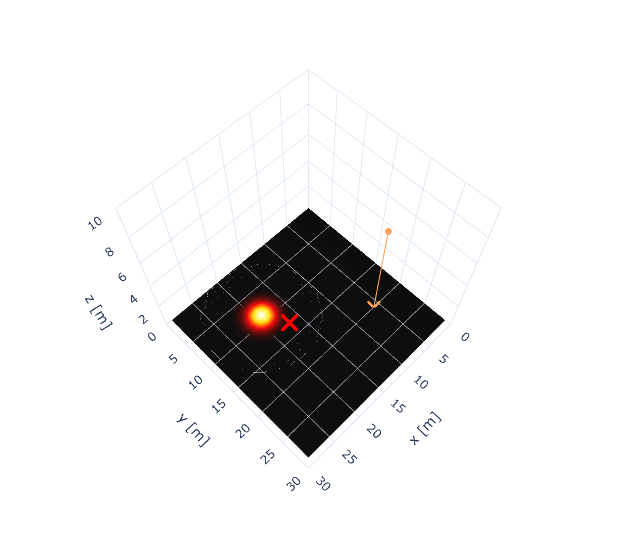

## Cargar los archivos

In [6]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "indicios-1-agentes-1"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_1 = process_all(testing_path)

successful_df_exp1_1 = combined_data_exp1_1[combined_data_exp1_1["Found"]]

In [7]:
print(combined_data_exp1_1)

       Strategy  Number of Agents  Steps Steps finder Distance  Found
0     ldfs-heur                 1   41.0         41.0  49.1127   True
1     ldfs-heur                 1   12.0         12.0  13.2426   True
2     ldfs-heur                 1   35.0         35.0  44.3553   True
3     ldfs-heur                 1   15.0         15.0  17.0711   True
4     ldfs-heur                 1   25.0         25.0  30.6274   True
...         ...               ...    ...          ...      ...    ...
3995  expanding                 1   11.0         11.0  14.3137   True
3996  expanding                 1   35.0         35.0  39.5563   True
3997  expanding                 1   35.0         35.0  37.8995   True
3998  lawnmower                 1   90.0         None  88.2426  False
3999  expanding                 1   35.0         35.0  37.8995   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [8]:
# Descripción general de los datos
combined_data_exp1_1.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,27.810,10.476051,11.0,11.0,33.0,35.0,35.0
lawnmower,1000.0,83.861,21.265604,10.0,90.0,90.0,90.0,91.0
ldfs-heur,1000.0,23.617,12.035496,11.0,13.0,15.0,36.0,41.0
ldfs-myop,1000.0,24.419,15.763627,11.0,15.0,18.0,31.0,90.0


In [9]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_1.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,35.0
lawnmower,90.0
ldfs-heur,15.0
ldfs-myop,13.0


In [10]:
combined_data_exp1_1.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000.0,40.0,35.0,75.0
lawnmower,1000,35,88.2426,470
ldfs-heur,1000.0,73.0,21.2132,74.0
ldfs-myop,1000.0,216.0,15.5563,48.0


#### Histogramas

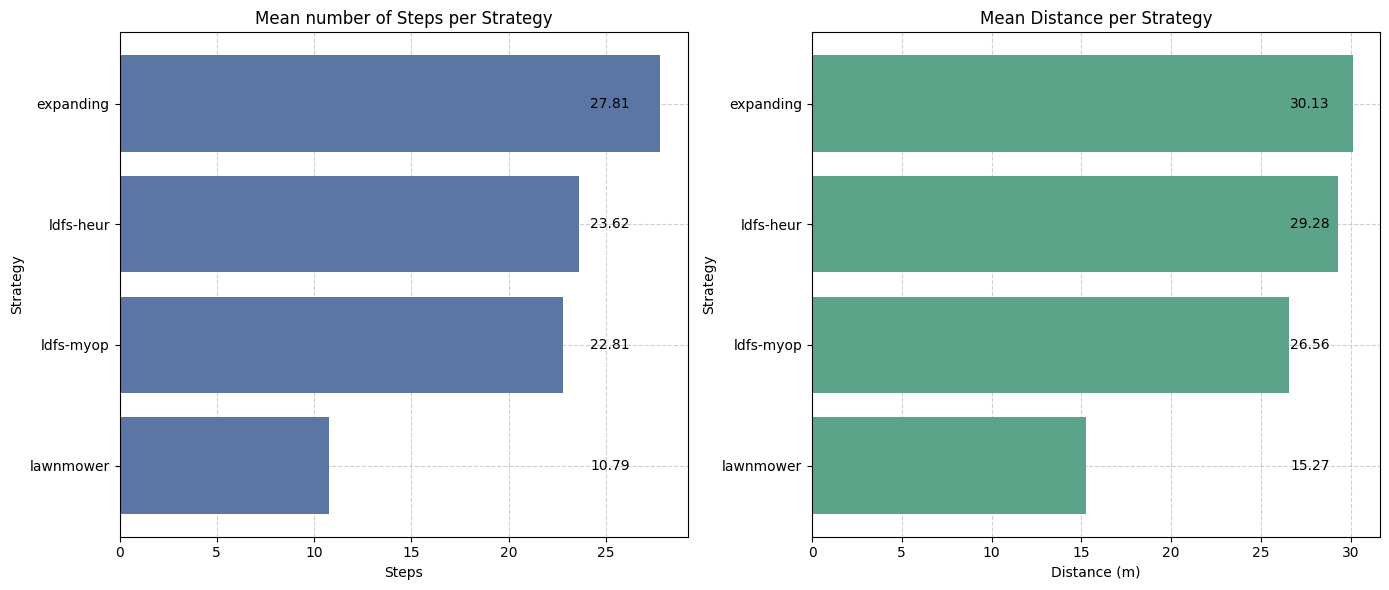

In [11]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_1.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_1.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max - 5), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(min(bar.get_width() + 20, x_max -5), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-1-1-peq/histo-pasos-peq-1-1.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [12]:
execution_data = []

for strategy, group in combined_data_exp1_1.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [13]:
global_xmin = combined_data_exp1_1["Steps"].min()
global_xmax = combined_data_exp1_1["Steps"].max()
global_ymax = combined_data_exp1_1.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas/exp-1-1-peq/histo-dist-peq-1-1.pdf")
fig_hist.show()

In [14]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)


fig_combined.write_image("graficas/exp-1-1-peq/histo-dist-comb-peq-1-1.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [15]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-1-1-peq/cdf-peq-1-1.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [16]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_1,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-1-1-peq/boxplot-peq-1-1.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [17]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_1.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)

success_stats

,num_attempts,successes,success_rate
Strategy,,,
expanding,1000,1000,100.0
lawnmower,1000,78,7.8
ldfs-heur,1000,1000,100.0
ldfs-myop,1000,976,97.6


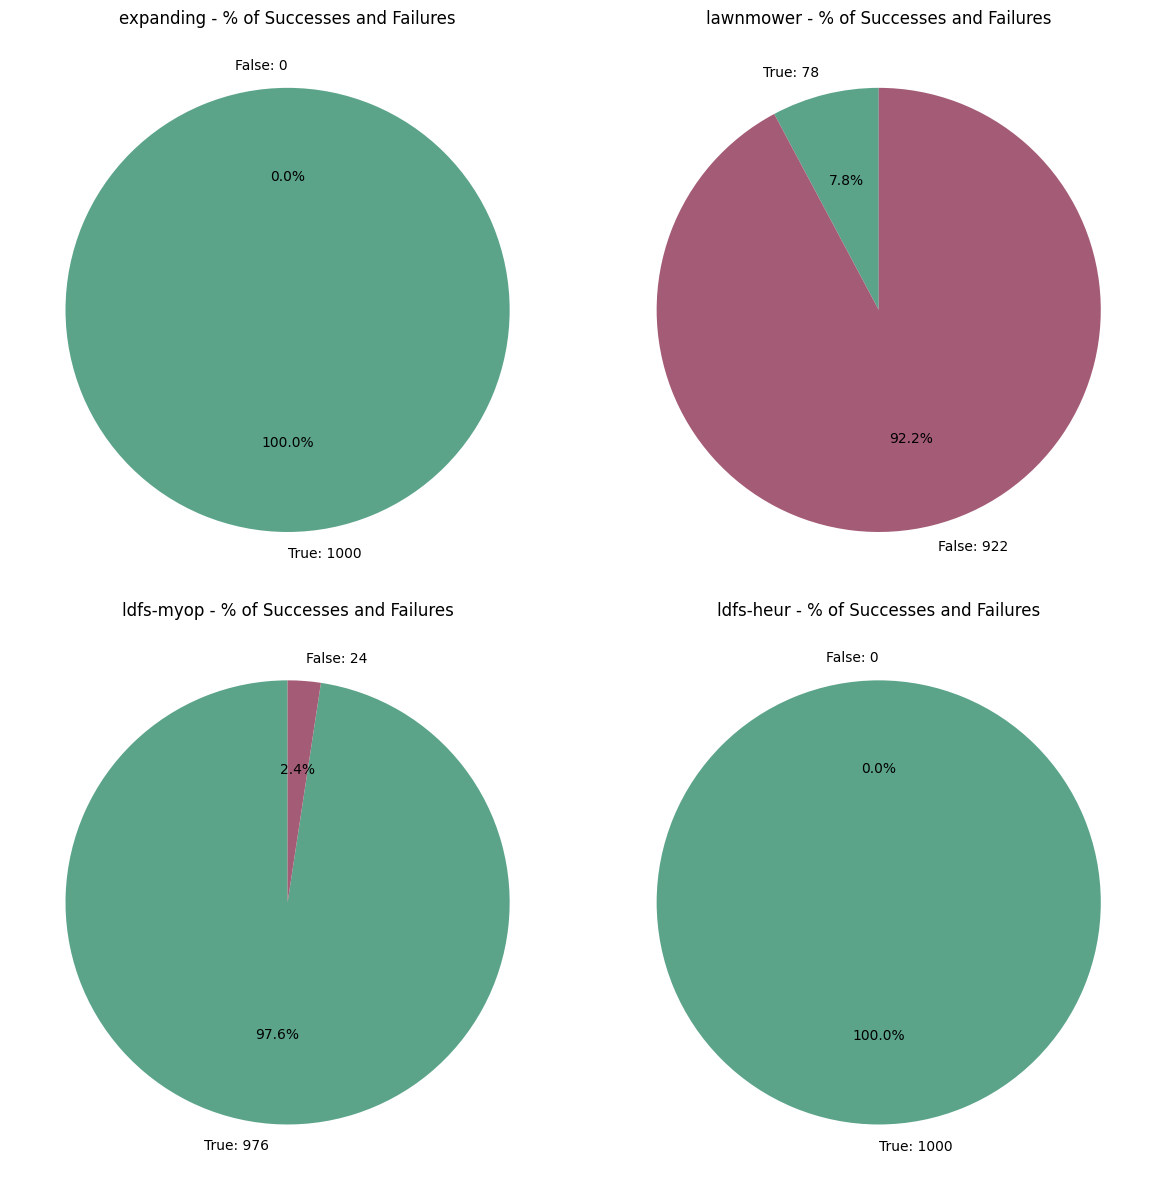

In [18]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(2, 2, figsize=(12,12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp1_1[combined_data_exp1_1["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


# ax_total = axes[len(strategies)]
# found_counts_total = combined_data_exp1_1["Found"].value_counts()
# values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
# labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

# ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
# ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Quitar el el 6 gráfico de la malla
# for j in range(len(strategies), len(axes)):
#     fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-1-1-peq/pie-exito-peq-1-1.pdf")
plt.show()

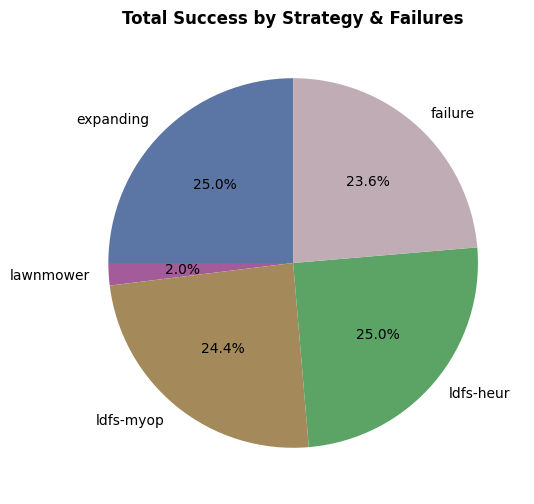

In [19]:
success_counts = combined_data_exp1_1[combined_data_exp1_1["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp1_1["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-1-1-peq/pie-exito-total-peq-1-1.pdf")
plt.show()

# Caso de estudio 1: Escenario 2 (`fixed`)
- indicios: 1, posición fija
- agentes: 1, posición fija
- escenario: pequeño


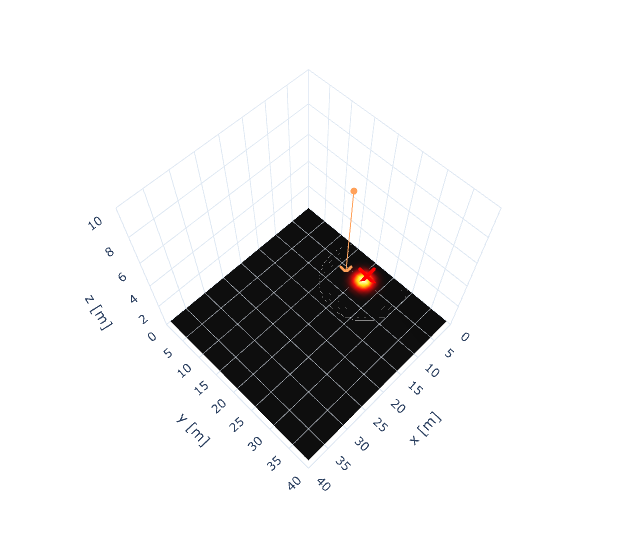

## Cargar los archivos

In [20]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "indicios-1-agentes-1-fixed"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_2 = process_all(testing_path)

successful_df_exp1_2 = combined_data_exp1_2[combined_data_exp1_2["Found"]]

In [21]:
print(combined_data_exp1_2)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     lawnmower                 1   30.0         30.0      29.0   True
1     lawnmower                 1   26.0         26.0      25.0   True
2     lawnmower                 1   25.0         25.0      24.0   True
3     lawnmower                 1   63.0         63.0      61.0   True
4     lawnmower                 1  100.0         None      97.0  False
...         ...               ...    ...          ...       ...    ...
3995  expanding                 1  100.0         None  100.8284  False
3996  expanding                 1  100.0         None  100.8284  False
3997  expanding                 1  100.0         None  100.8284  False
3998  expanding                 1   56.0         56.0   56.8284   True
3999  ldfs-heur                 1   17.0         17.0   21.9706   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [22]:
# Descripción general de los datos
combined_data_exp1_2.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,86.983,19.067624,56.0,61.0,100.0,100.0,100.0
lawnmower,1000.0,45.411,22.725107,24.0,27.0,31.0,62.0,100.0
ldfs-heur,1000.0,25.143,16.488129,11.0,14.0,17.0,35.0,100.0
ldfs-myop,1000.0,21.543,10.138982,11.0,14.0,17.0,28.0,73.0


In [23]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_2.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,100.0
lawnmower,30.0
ldfs-heur,17.0
ldfs-myop,17.0


In [24]:
combined_data_exp1_2.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,9,100.8284,681
lawnmower,1000.0,20.0,29.0,85.0
ldfs-heur,1000.0,25.0,21.9706,133.0
ldfs-myop,1000.0,22.0,21.9706,133.0


#### Histogramas

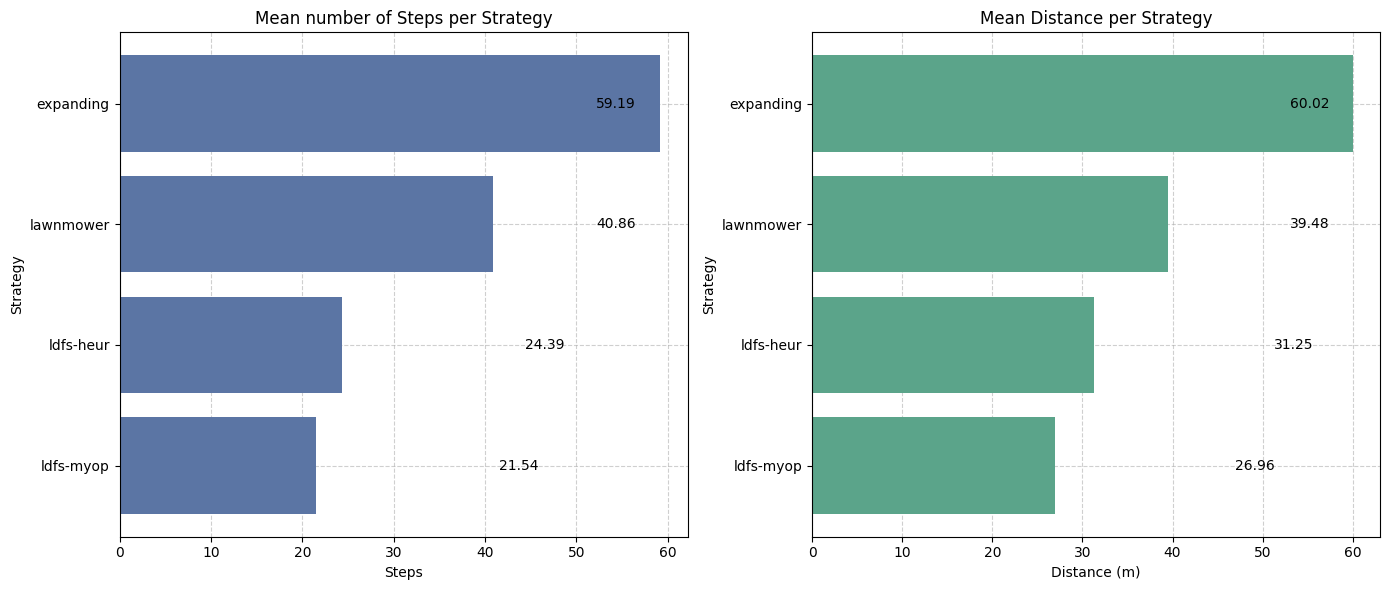

In [25]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_2.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_2.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max - 10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(min(bar.get_width() + 20, x_max -10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-1-2-peq-fixed/histo-pasos-peq-1-2-fixed.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [26]:
execution_data = []

for strategy, group in combined_data_exp1_2.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [27]:
global_xmin = combined_data_exp1_2["Steps"].min()
global_xmax = combined_data_exp1_2["Steps"].max()
global_ymax = combined_data_exp1_2.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=1,
    cols=4,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = 1
    col = idx +1 # % 2 + 1

    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=500,
    width=2000,
    bargap=0.1,
)

fig_hist.write_image("graficas/exp-1-2-peq-fixed/histo-dist-peq-1-2-fixed.pdf")
fig_hist.show()

In [28]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas/exp-1-2-peq-fixed/histo-dist-comb-peq-1-2-fixed.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [29]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-1-2-peq-fixed/cdf-peq-1-2-fixed.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [30]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_2,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-1-2-peq-fixed/boxplot-peq-1-2-fixed.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [31]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_2.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
success_stats

,num_attempts,successes,success_rate
Strategy,,,
expanding,1000,319,31.9
lawnmower,1000,923,92.3
ldfs-heur,1000,990,99.0
ldfs-myop,1000,1000,100.0


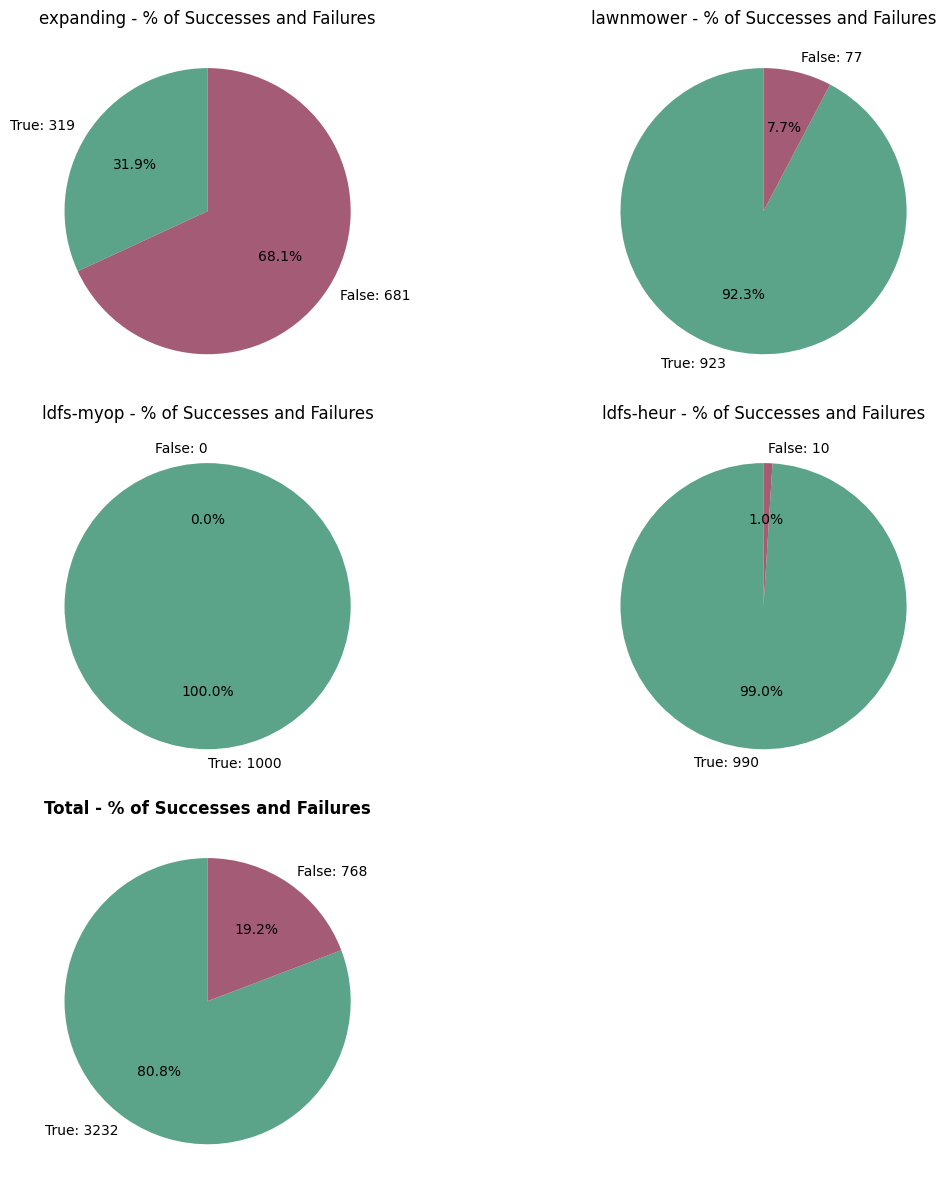

In [32]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp1_2[combined_data_exp1_2["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp1_2["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-1-2-peq-fixed/pie-exito-peq-1-2-fixed.pdf")
plt.show()

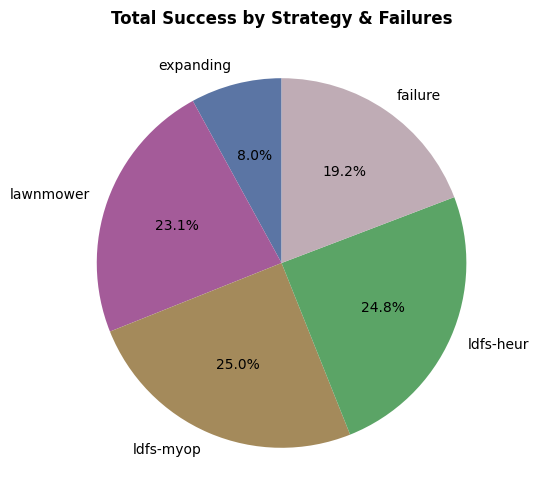

In [33]:
success_counts = combined_data_exp1_2[combined_data_exp1_2["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp1_2["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-1-2-peq-fixed/pie-exito-total-peq-1-2-fixed.pdf")
plt.show()

# Caso de estudio 1: Escenario 3 (`random`)
- indicios: 1, posición aleatoria
- agentes: 1, posición fija
- escenario: pequeño


## Cargar los archivos

In [34]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "indicios-1-agentes-1-random"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_3 = process_all(testing_path)

successful_df_exp1_3 = combined_data_exp1_3[combined_data_exp1_3["Found"]]

In [35]:
print(combined_data_exp1_3)

       Strategy  Number of Agents  Steps Steps finder Distance  Found
0     expanding                 1    9.0          9.0      9.0   True
1     expanding                 1  100.0         None    100.0  False
2     expanding                 1   73.0         73.0     73.0   True
3     expanding                 1  100.0         None    100.0  False
4     expanding                 1  100.0         None    100.0  False
...         ...               ...    ...          ...      ...    ...
3995  ldfs-heur                 1    6.0          6.0   8.4853   True
3996  ldfs-heur                 1    9.0          9.0  12.3137   True
3997  ldfs-heur                 1   20.0         20.0  24.5563   True
3998  ldfs-heur                 1   35.0         35.0  37.9706   True
3999  ldfs-heur                 1   13.0         13.0  13.8284   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [36]:
# Descripción general de los datos
combined_data_exp1_3.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,79.575,32.390361,1.0,59.0,100.0,100.00,100.0
lawnmower,1000.0,86.039,27.781132,1.0,99.0,100.0,100.00,100.0
ldfs-heur,1000.0,15.882,8.234311,1.0,10.0,15.0,22.00,50.0
ldfs-myop,1000.0,38.824,38.795284,1.0,10.0,16.0,95.25,100.0


In [37]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_3.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,100.0
lawnmower,100.0
ldfs-heur,11.0
ldfs-myop,100.0


In [38]:
combined_data_exp1_3.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,88,100.0,633
lawnmower,1000,82,97.0,747
ldfs-heur,1000.0,348.0,1.4142,15.0
ldfs-myop,1000.0,478.0,1.4142,15.0


#### Histogramas

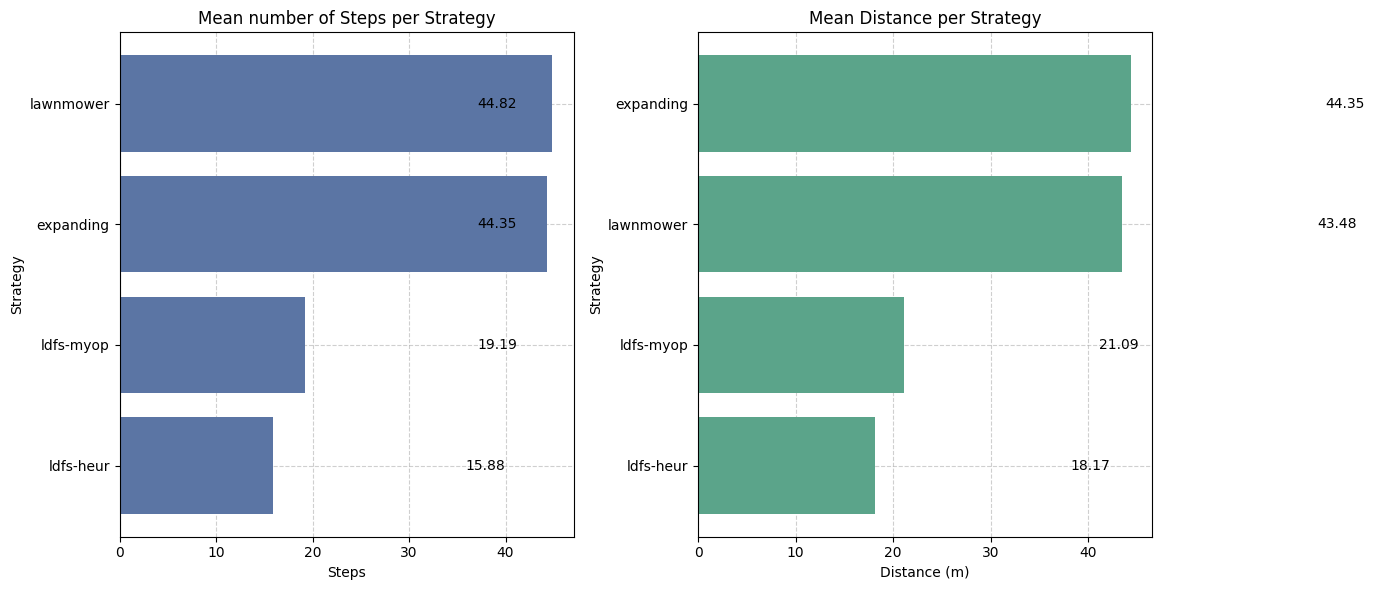

In [39]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_3.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_3.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max -10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-1-3-peq-random/histo-pasos-1-3-peq-random.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [40]:
execution_data = []

for strategy, group in combined_data_exp1_3.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [41]:
global_xmin = combined_data_exp1_3["Steps"].min()
global_xmax = combined_data_exp1_3["Steps"].max()
global_ymax = combined_data_exp1_3.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas/exp-1-3-peq-random/histo-dist-1-3-peq-random.pdf")
fig_hist.show()

In [42]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas/exp-1-3-peq-random/histo-dist-comb-1-3-peq-random.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [43]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-1-3-peq-random/cdf-1-3-peq-random.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [44]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_3,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-1-3-peq-random/boxplot-1-3-peq-random.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [45]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_3.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
success_stats

,num_attempts,successes,success_rate
Strategy,,,
expanding,1000,367,36.7
lawnmower,1000,253,25.3
ldfs-heur,1000,1000,100.0
ldfs-myop,1000,757,75.7


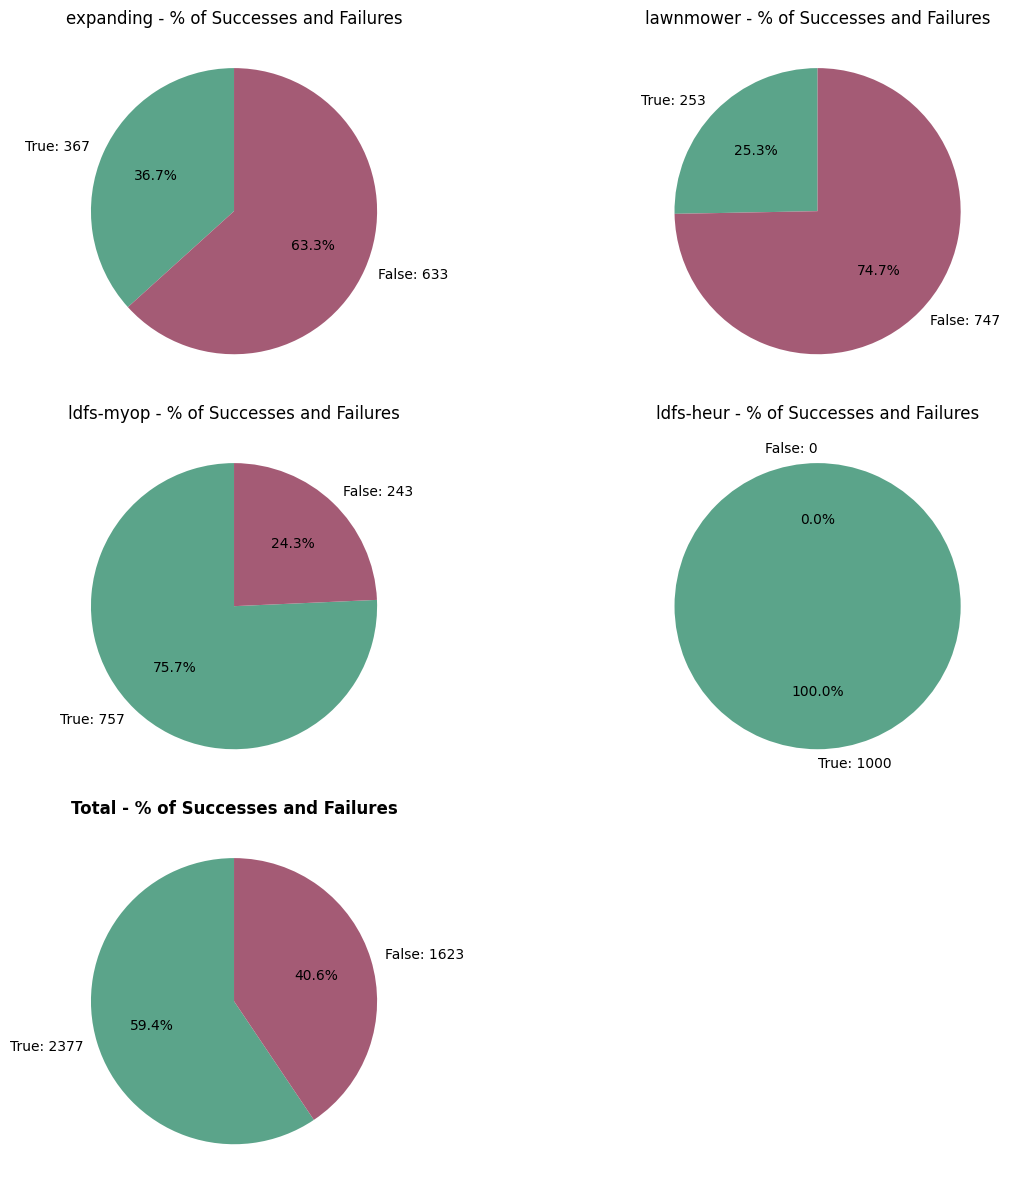

In [46]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp1_3[combined_data_exp1_3["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp1_3["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-1-3-peq-random/pie-exito-1-3-peq-random.pdf")
plt.show()

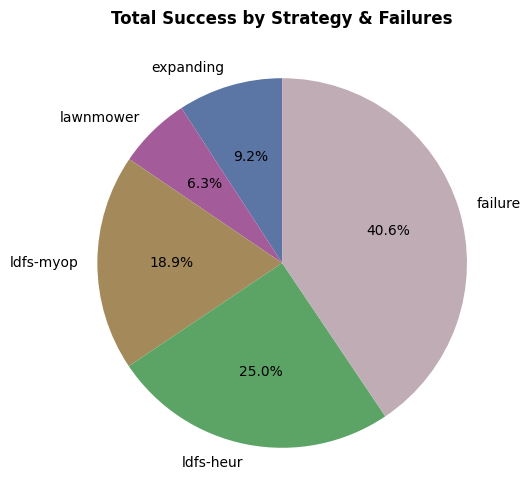

In [47]:
success_counts = combined_data_exp1_3[combined_data_exp1_3["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp1_3["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-1-3-peq-random/pie-exito-total-1-3-peq-random.pdf")
plt.show()

# Caso de estudio 2 (mediano): Escenario 1
- indicios: 1, posición fija
- agentes: 1, posición aleatoria desde el borde
- escenario: mediano

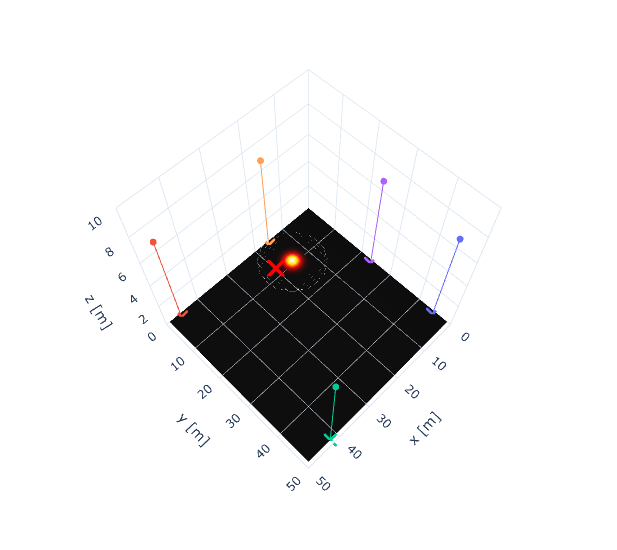

## Cargar los archivos

In [48]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "mediano-indicios-1-agentes-1"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp2_1 = process_all(testing_path)

successful_df_exp2_1 = combined_data_exp2_1[combined_data_exp2_1["Found"]]

In [49]:
print(combined_data_exp2_1)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     ldfs-heur                 1   41.0         41.0   50.7696   True
1     ldfs-heur                 1    6.0          6.0    8.4853   True
2     ldfs-heur                 1   24.0         24.0   27.7279   True
3     ldfs-heur                 1   70.0         70.0   79.1127   True
4     ldfs-heur                 1   32.0         32.0   40.5269   True
...         ...               ...    ...          ...       ...    ...
3995  expanding                 1  200.0         None  204.1421  False
3996  expanding                 1  147.0        147.0  154.0416   True
3997  expanding                 1  200.0         None  200.4142  False
3998  expanding                 1  200.0         None  204.5563  False
3999  lawnmower                 1   30.0         30.0   42.4264   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [50]:
# Descripción general de los datos
combined_data_exp2_1.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,157.740,57.530341,4.0,145.0,147.0,200.0,200.0
lawnmower,1000.0,123.839,34.157954,25.0,113.0,139.0,147.0,147.0
ldfs-heur,1000.0,42.645,20.033780,6.0,28.0,39.5,66.0,93.0
ldfs-myop,1000.0,131.378,83.228181,6.0,24.0,200.0,200.0,200.0


In [51]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp2_1.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,200.0
lawnmower,147.0
ldfs-heur,70.0
ldfs-myop,200.0


In [52]:
combined_data_exp2_1.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,85,200.0,57
lawnmower,1000.0,109.0,35.3553,39.0
ldfs-heur,1000.0,156.0,8.4853,29.0
ldfs-myop,1000.0,508.0,8.4853,29.0


#### Histogramas

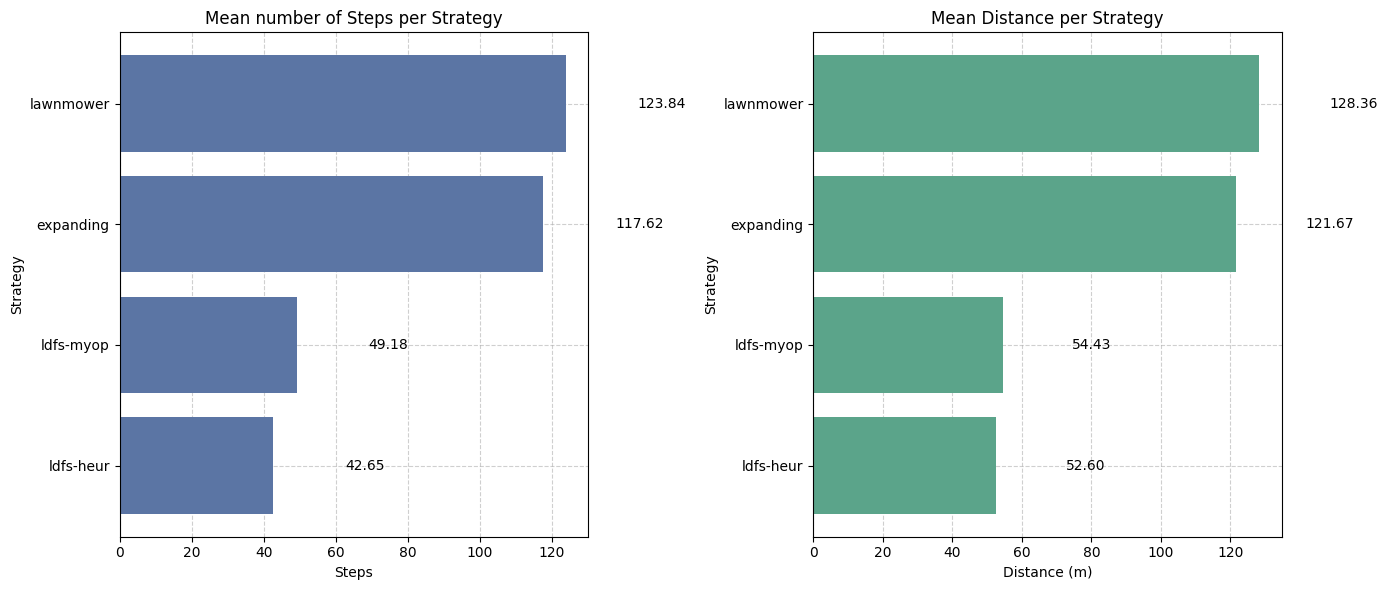

In [53]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp2_1.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp2_1.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-2-1-med/histo-pasos-2-1-med.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [54]:
execution_data = []

for strategy, group in combined_data_exp2_1.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [55]:
global_xmin = combined_data_exp2_1["Steps"].min()
global_xmax = combined_data_exp2_1["Steps"].max()
global_ymax = combined_data_exp2_1.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)
fig_hist.write_image("graficas/exp-2-1-med/histo-dist-2-1-med.pdf")
fig_hist.show()

In [56]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

plt.savefig("graficas/exp-2-1-med/histo-dist-comb-2-1-med.pdf")
fig_combined.show()


<Figure size 640x480 with 0 Axes>

#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [57]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

plt.savefig("graficas/exp-2-1-med/cdf-2-1-med.pdf")
fig_cumulative.show()

<Figure size 640x480 with 0 Axes>

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [58]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp2_1,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-2-1-med/boxplot-2-1-med.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [59]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp2_1.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000        513          51.3
lawnmower          1000       1000         100.0
ldfs-heur          1000       1000         100.0
ldfs-myop          1000        455          45.5


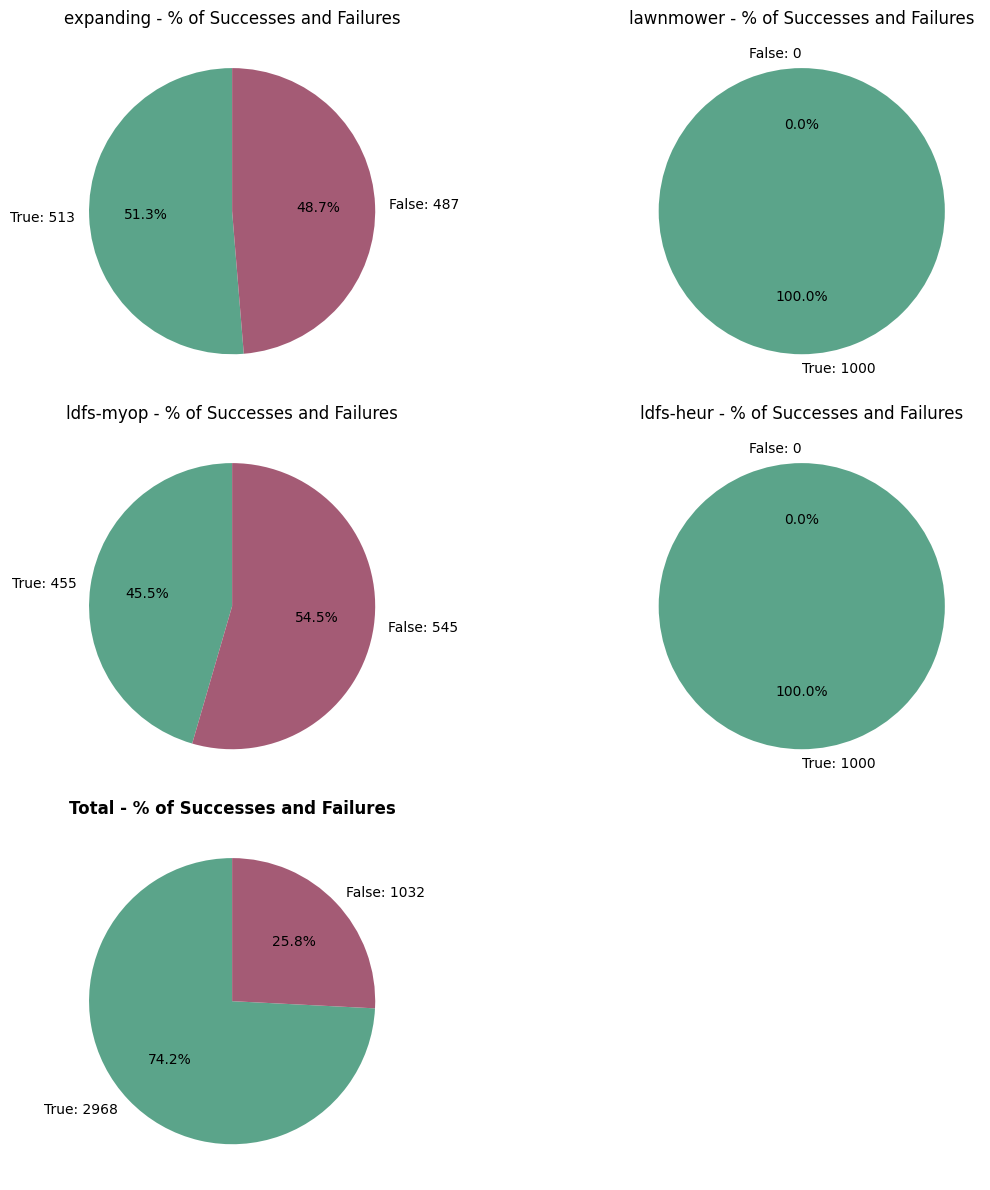

In [60]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp2_1[combined_data_exp2_1["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp2_1["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-2-1-med/pie-exito-2-1-med.pdf")
plt.show()

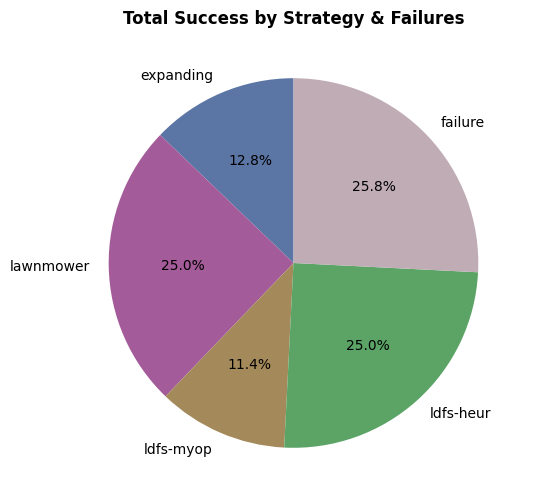

In [61]:
success_counts = combined_data_exp2_1[combined_data_exp2_1["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp2_1["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-2-1-med/pie-exito-total-2-1-med.pdf")
plt.show()

# Caso de estudio 2 (mediano): Escenario 2 (`fixed`)
- indicios: 1, posición fija
- agentes: 1, posición fija
- escenario: mediano

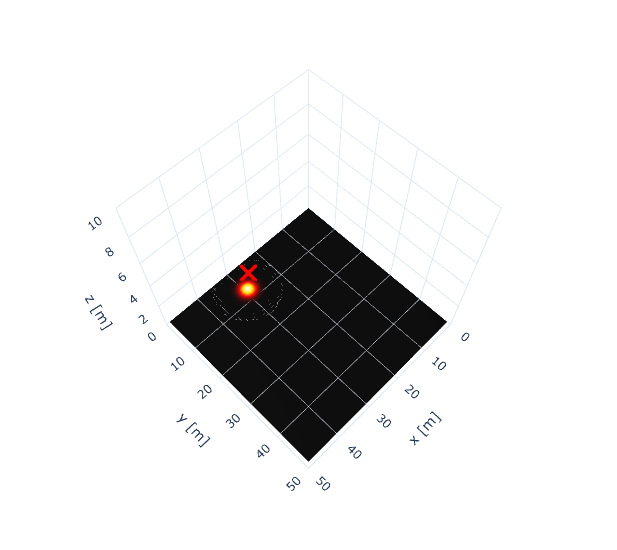

## Cargar los archivos

In [62]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "mediano-indicios-1-agentes-1-fixed"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp2_2 = process_all(testing_path)

successful_df_exp2_2 = combined_data_exp2_2[combined_data_exp2_2["Found"]]

In [63]:
print(combined_data_exp2_2)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     lawnmower                 1  200.0         None  197.0711  False
1     lawnmower                 1  197.0        197.0  195.0711   True
2     ldfs-myop                 1  199.0        199.0  220.5513   True
3     ldfs-myop                 1  200.0         None  214.3797  False
4     ldfs-myop                 1   73.0         73.0   69.3553   True
...         ...               ...    ...          ...       ...    ...
3995  expanding                 1  156.0        156.0  163.4558   True
3996  expanding                 1  200.0         None  207.4558  False
3997  expanding                 1  157.0        157.0  164.4558   True
3998  expanding                 1  160.0        160.0  167.4558   True
3999  expanding                 1  161.0        161.0  168.4558   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [64]:
# Descripción general de los datos
combined_data_exp2_2.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,175.675,21.482898,153.0,156.0,160.0,200.0,200.0
lawnmower,1000.0,193.324,6.182171,179.0,192.0,195.0,198.0,200.0
ldfs-heur,1000.0,38.246,18.701584,24.0,27.0,30.0,48.0,174.0
ldfs-myop,1000.0,132.815,55.972580,30.0,81.0,131.5,200.0,200.0


In [65]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp2_2.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,200.0
lawnmower,200.0
ldfs-heur,30.0
ldfs-myop,200.0


In [66]:
combined_data_exp2_2.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,10,207.4558,436
lawnmower,1000.0,18.0,195.0711,166.0
ldfs-heur,1000.0,26.0,31.2426,133.0
ldfs-myop,1000,826,213.2082,5


#### Histogramas

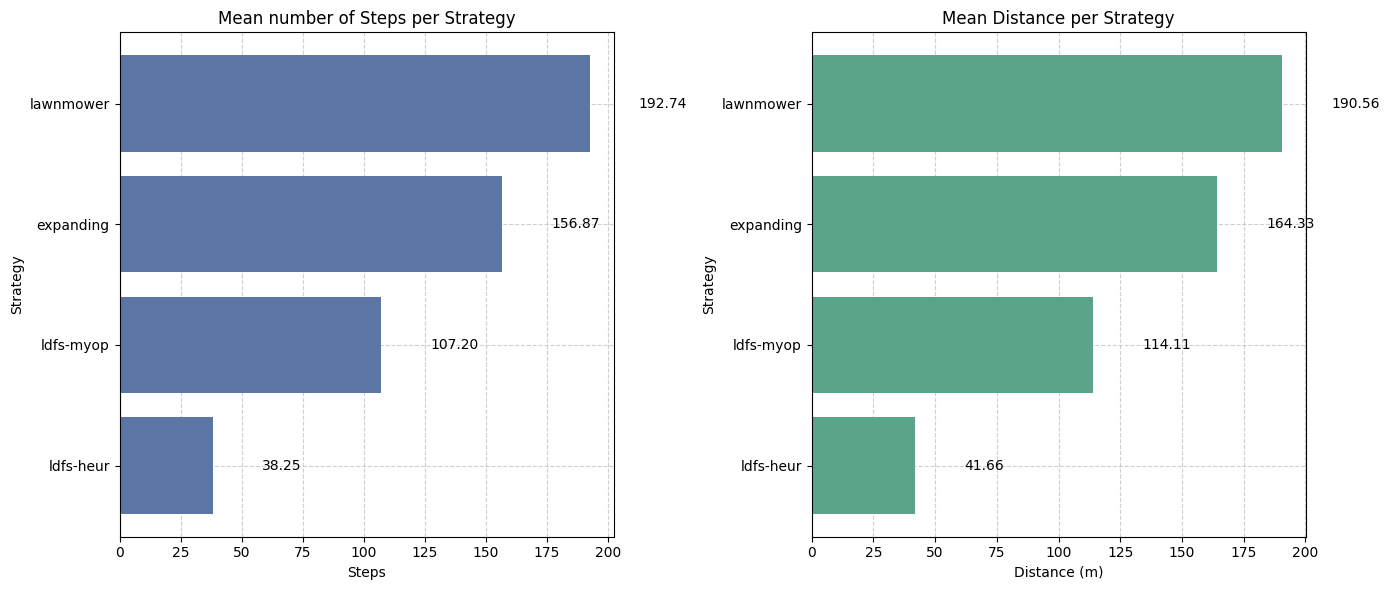

In [67]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp2_2.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp2_2.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-2-2-med-fixed/histo-pasos-2-2-med-fixed.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [68]:
execution_data = []

for strategy, group in combined_data_exp2_2.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [69]:
global_xmin = combined_data_exp2_2["Steps"].min()
global_xmax = combined_data_exp2_2["Steps"].max()
global_ymax = combined_data_exp2_2.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)
fig_hist.write_image("graficas/exp-2-2-med-fixed/histo-dist-2-2-med-fixed.pdf")
fig_hist.show()

In [70]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas/exp-2-2-med-fixed/histo-dist-comb-2-2-med-fixed.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [71]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-2-2-med-fixed/cdf-2-2-med-fixed.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [72]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp2_2,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-2-2-med-fixed/boxplot-2-2-med-fixed.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [73]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp2_2.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000        564          56.4
lawnmower          1000        919          91.9
ldfs-heur          1000       1000         100.0
ldfs-myop          1000        724          72.4


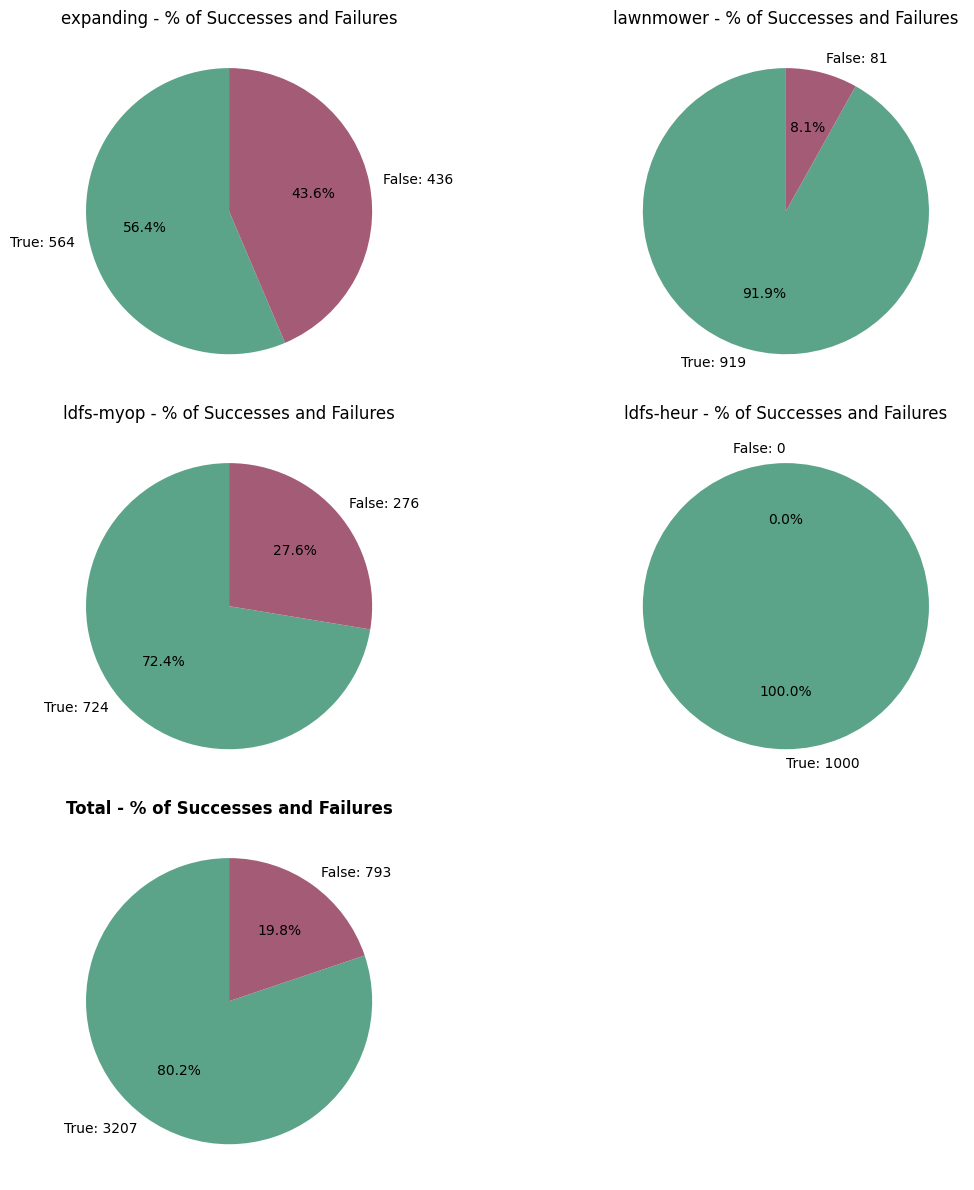

In [74]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp2_2[combined_data_exp2_2["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp2_2["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-2-2-med-fixed/pie-exito-2-2-med-fixed.pdf")
plt.show()

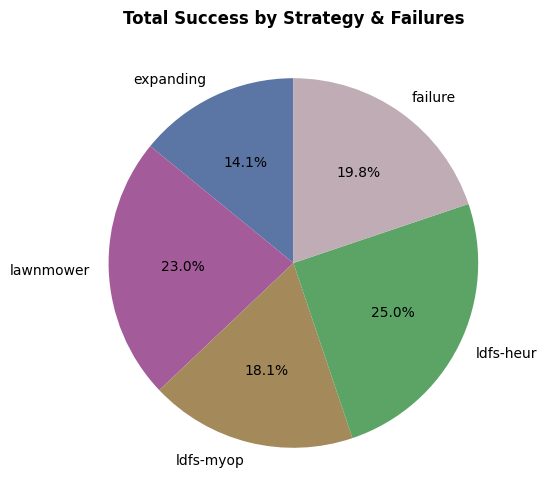

In [75]:
success_counts = combined_data_exp2_2[combined_data_exp2_2["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp2_2["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-2-2-med-fixed/pie-exito-total-2-2-med-fixed.pdf")
plt.show()

# Caso de estudio 2 (mediano): Escenario 3 (`random`)
- indicios: 1, posición aleatoria
- agentes: 1, posición fija
- escenario: mediano


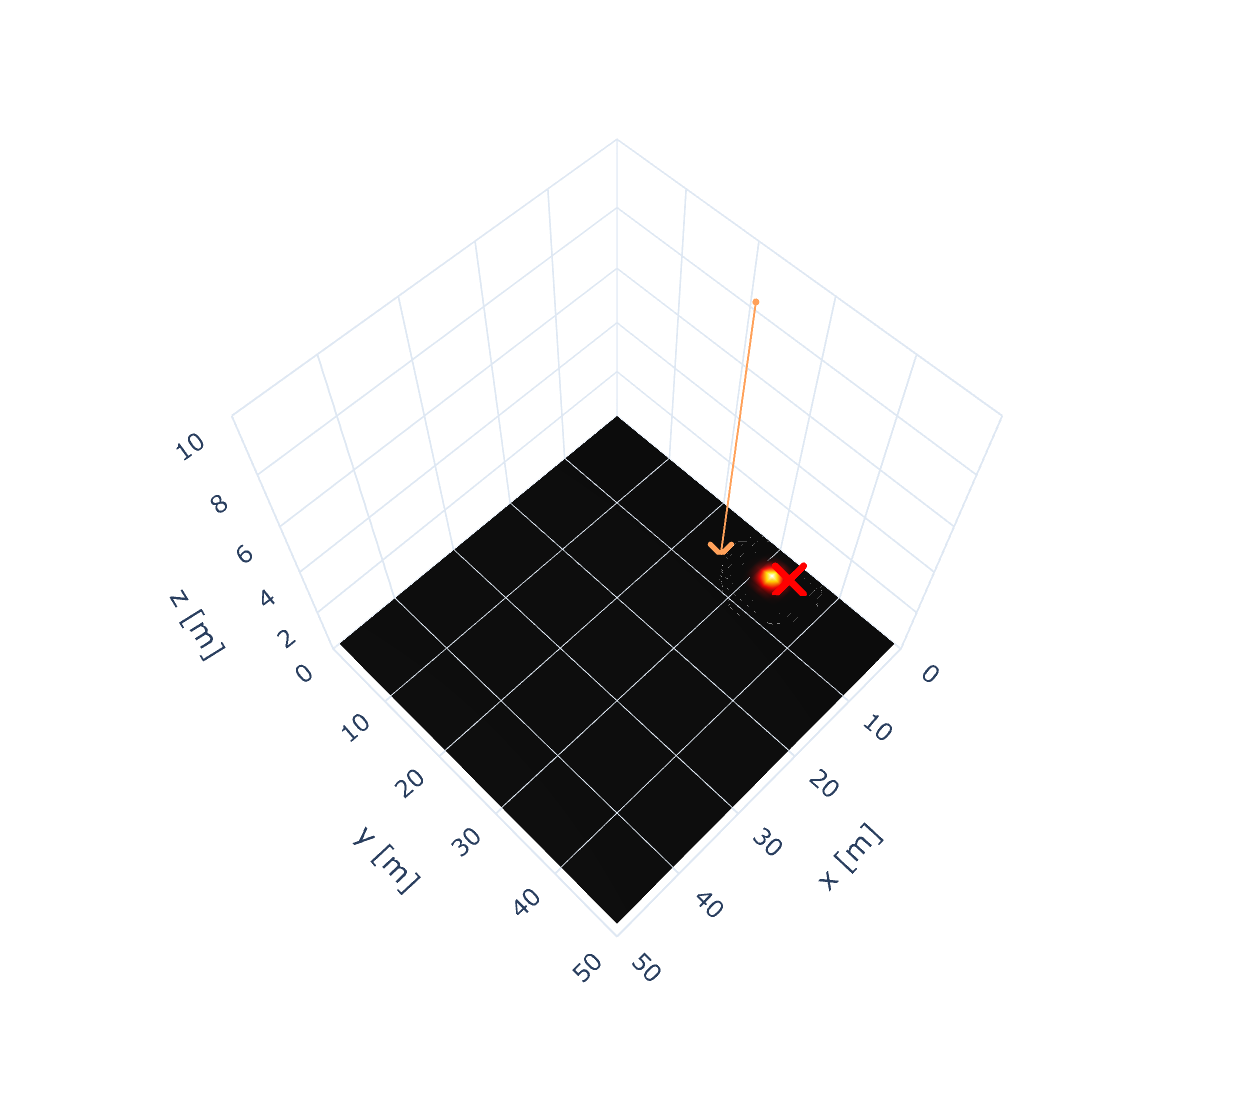

## Cargar los archivos

In [76]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "mediano-indicios-1-agentes-1-random"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp2_3 = process_all(testing_path)

successful_df_exp2_3 = combined_data_exp2_3[combined_data_exp2_3["Found"]]

In [77]:
print(combined_data_exp2_3)

       Strategy  Number of Agents  Steps Steps finder Distance  Found
0     expanding                 1  200.0         None    200.0  False
1     expanding                 1  200.0         None    200.0  False
2     expanding                 1  200.0         None    200.0  False
3     expanding                 1  200.0         None    200.0  False
4     expanding                 1  200.0         None    200.0  False
...         ...               ...    ...          ...      ...    ...
3995  ldfs-heur                 1   22.0         22.0  23.7279   True
3996  ldfs-heur                 1   10.0         10.0  11.6569   True
3997  ldfs-heur                 1   17.0         17.0  19.0711   True
3998  ldfs-heur                 1   36.0         36.0  41.4558   True
3999  ldfs-heur                 1    9.0          9.0   9.4142   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [78]:
# Descripción general de los datos
combined_data_exp2_3.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,160.742,66.438539,1.0,141.0,200.0,200.0,200.0
lawnmower,1000.0,177.334,52.039875,1.0,200.0,200.0,200.0,200.0
ldfs-heur,1000.0,20.890,10.265246,1.0,13.0,20.0,29.0,54.0
ldfs-myop,1000.0,98.763,86.702977,1.0,13.0,60.5,200.0,200.0


In [79]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp2_3.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,200.0
lawnmower,200.0
ldfs-heur,13.0
ldfs-myop,200.0


In [80]:
combined_data_exp2_3.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,143,200.0,667
lawnmower,1000,123,196.0,786
ldfs-heur,1000.0,495.0,8.2426,10.0
ldfs-myop,1000.0,624.0,8.2426,8.0


#### Histogramas

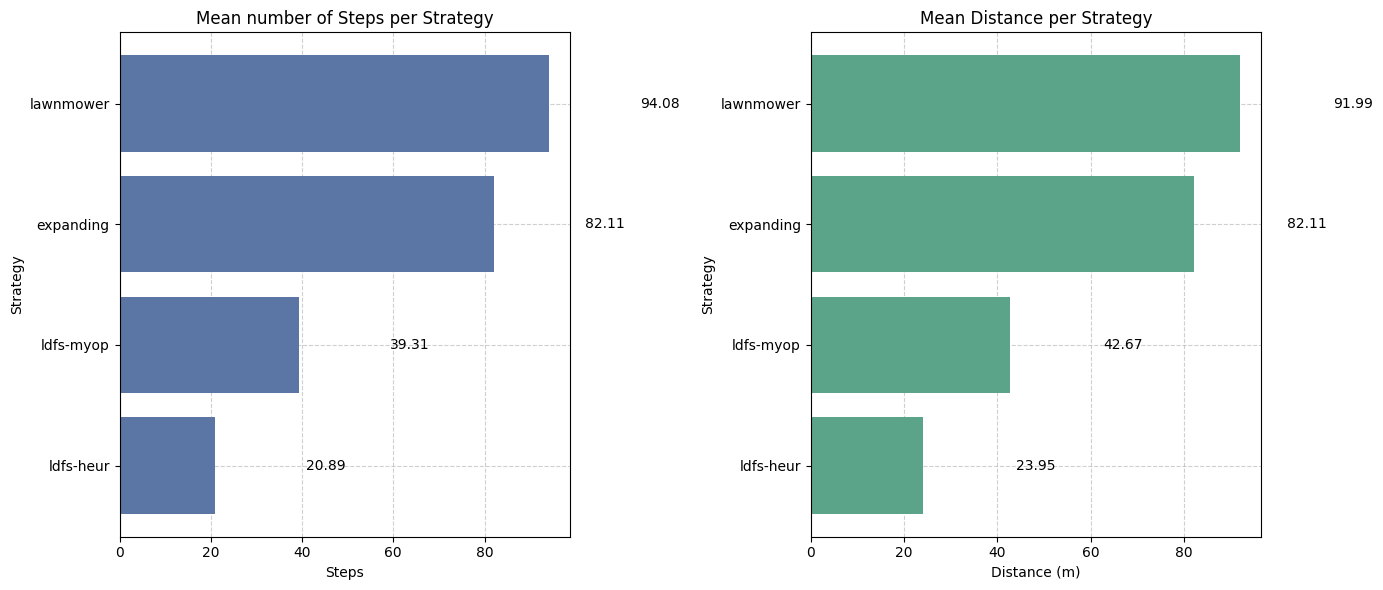

In [81]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp2_3.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp2_3.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-2-3-med-random/histo-pasos-2-3-med-random.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [82]:
execution_data = []

for strategy, group in combined_data_exp2_3.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [83]:
global_xmin = combined_data_exp2_3["Steps"].min()
global_xmax = combined_data_exp2_3["Steps"].max()
global_ymax = combined_data_exp2_3.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas/exp-2-3-med-random/histo-dist-2-3-med-random.pdf")
fig_hist.show()

In [84]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas/exp-2-3-med-random/histo-dist-comb-2-3-med-random.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [85]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-2-3-med-random/cdf-2-3-med-random.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [86]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp2_3,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-2-3-med-random/boxplot-2-3-med-random.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [87]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp2_3.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000        333          33.3
lawnmower          1000        214          21.4
ldfs-heur          1000       1000         100.0
ldfs-myop          1000        630          63.0


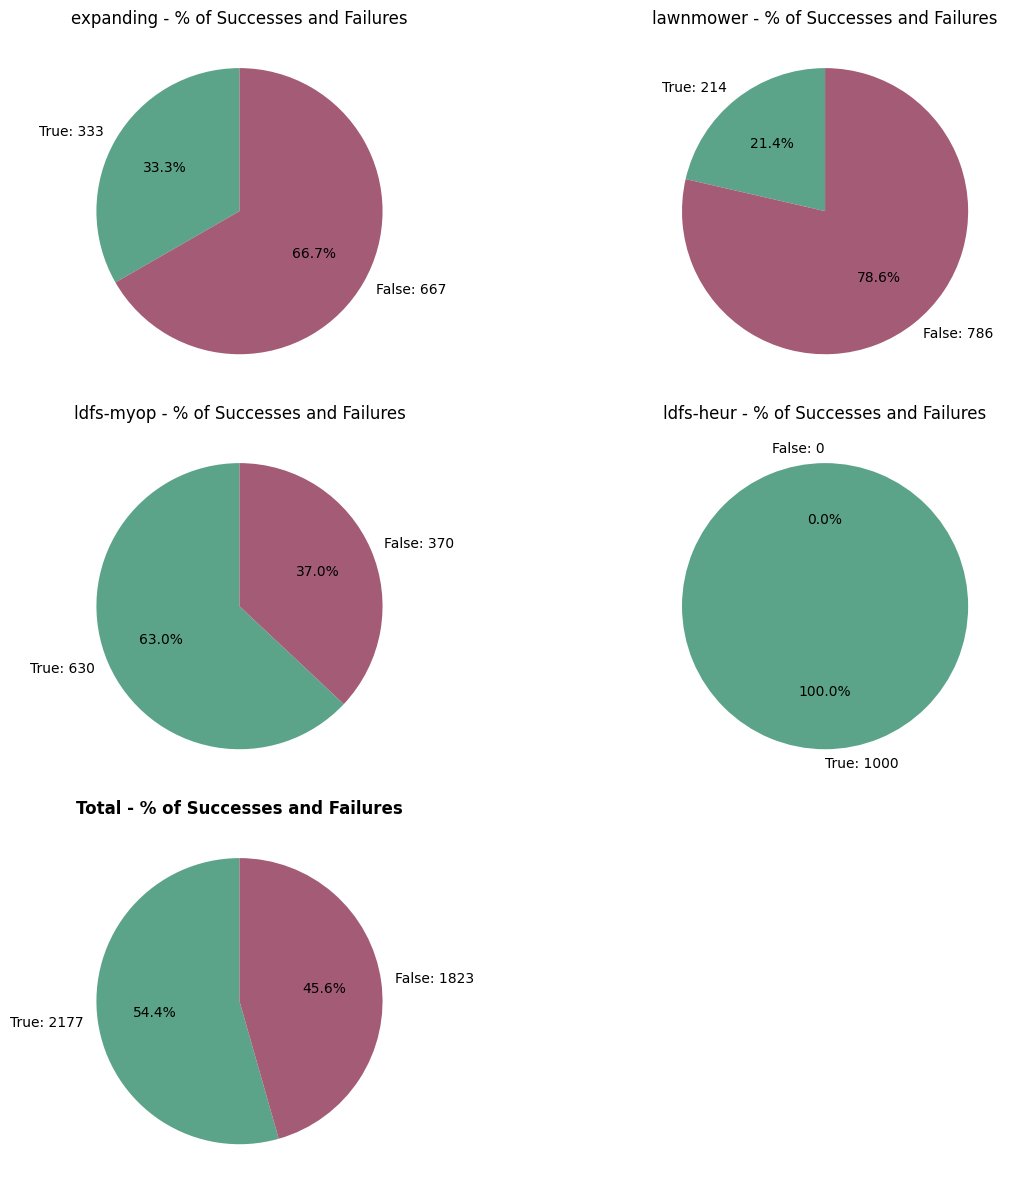

In [88]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp2_3[combined_data_exp2_3["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp2_3["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-2-3-med-random/pie-exito-2-3-med-random.pdf")
plt.show()

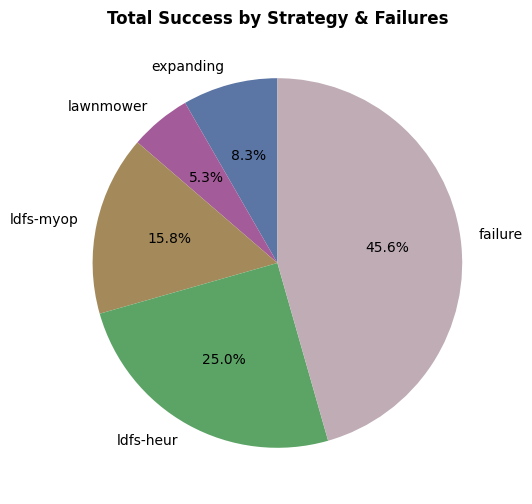

In [89]:
success_counts = combined_data_exp2_3[combined_data_exp2_3["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp2_3["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-2-3-med-random/pie-exito-total-2-3-med-random.pdf")
plt.show()

# Caso de estudio 3 (Grande): Escenario 1
- indicios: 1, posición fija
- agentes: 1, posición aleatoria desde el borde
- escenario: grande

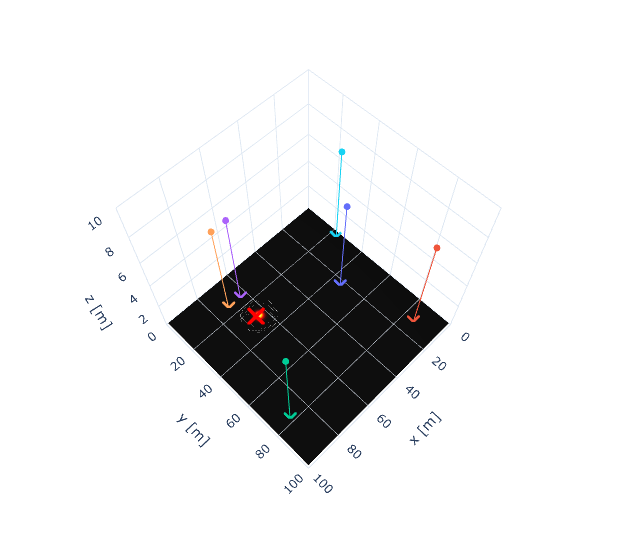

## Cargar los archivos

In [90]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "grande-indicios-1-agentes-1"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp3_1 = process_all(testing_path)

successful_df_exp3_1 = combined_data_exp3_1[combined_data_exp3_1["Found"]]

In [91]:
print(combined_data_exp3_1)

       Strategy  Number of Agents  Steps Steps finder   Distance  Found
0     expanding                 1  744.0         None     1488.0  False
1     expanding                 1   39.0         39.0    92.9117   True
2     expanding                 1  744.0         None  1501.2548  False
3     expanding                 1   39.0         39.0    87.9411   True
4     expanding                 1   39.0         39.0    78.8284   True
...         ...               ...    ...          ...        ...    ...
3995  ldfs-heur                 1   60.0         60.0   126.5097   True
3996  ldfs-heur                 1  918.0        918.0  1968.4835   True
3997  ldfs-heur                 1   40.0         40.0    98.7107   True
3998  ldfs-heur                 1    9.0          9.0    22.1421   True
3999  ldfs-heur                 1   15.0         15.0    39.9411   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [92]:
# Descripción general de los datos
combined_data_exp3_1.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,125.266,232.953903,13.0,39.0,39.0,39.00,744.0
lawnmower,1000.0,211.302,185.538517,44.0,53.0,204.0,241.25,538.0
ldfs-heur,1000.0,107.383,186.679167,2.0,14.0,25.0,116.25,1200.0
ldfs-myop,1000.0,606.103,488.698761,2.0,104.5,514.5,1200.00,1200.0


In [93]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp3_1.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,39.0
lawnmower,47.0
ldfs-heur,14.0
ldfs-myop,1200.0


In [94]:
combined_data_exp3_1.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000.0,77.0,78.0,47.0
lawnmower,1000,147,106.4264,40
ldfs-heur,1000.0,679.0,35.1127,9.0
ldfs-myop,1000.0,910.0,14.1421,6.0


#### Histogramas

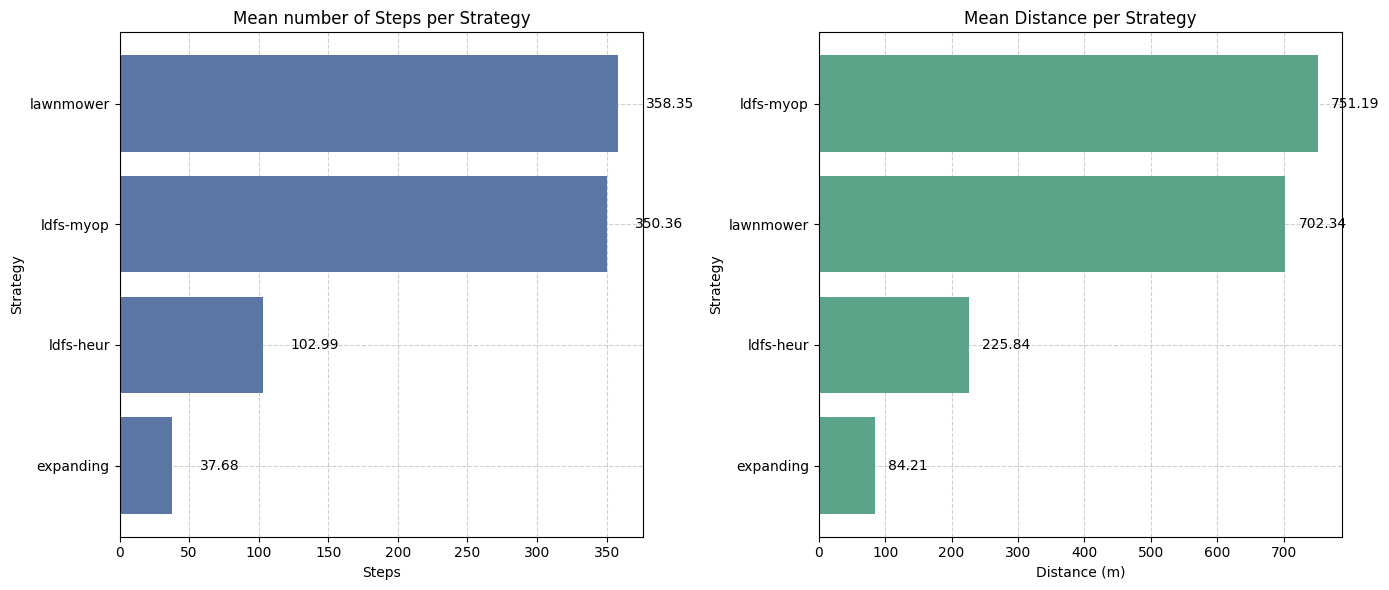

In [95]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp3_1.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp3_1.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-3-1-grande/histo-pasos-3-1-grande.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [96]:
execution_data = []

for strategy, group in combined_data_exp3_1.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [97]:
global_xmin = combined_data_exp3_1["Steps"].min()
global_xmax = combined_data_exp3_1["Steps"].max()
global_ymax = combined_data_exp3_1.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp3_1[combined_data_exp3_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas/exp-3-1-grande/histo-dist-3-1-grande.pdf")
fig_hist.show()

In [98]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp3_1[combined_data_exp3_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas/exp-3-1-grande/histo-dist-comb-3-1-grande.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [99]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp3_1[combined_data_exp3_1['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-3-1-grande/cdf-3-1-grande.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [100]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp3_1,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp3_1[combined_data_exp3_1['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-3-1-grande/boxplot-3-1-grande.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [101]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp3_1.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000        876          87.6
lawnmower          1000        518          51.8
ldfs-heur          1000        996          99.6
ldfs-myop          1000        699          69.9


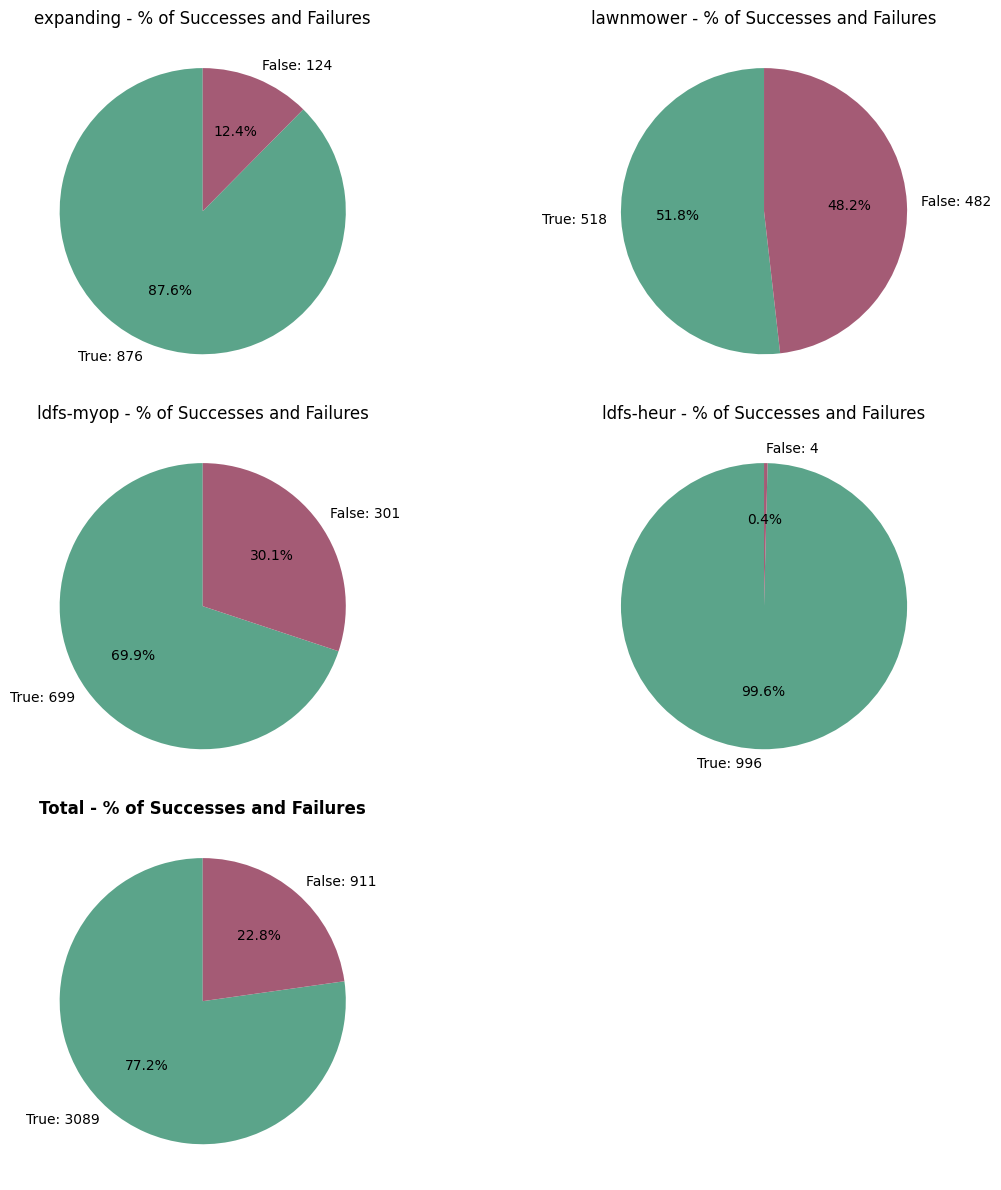

In [102]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp3_1[combined_data_exp3_1["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp3_1["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-3-1-grande/pie-exito-3-1-grande.pdf")
plt.show()

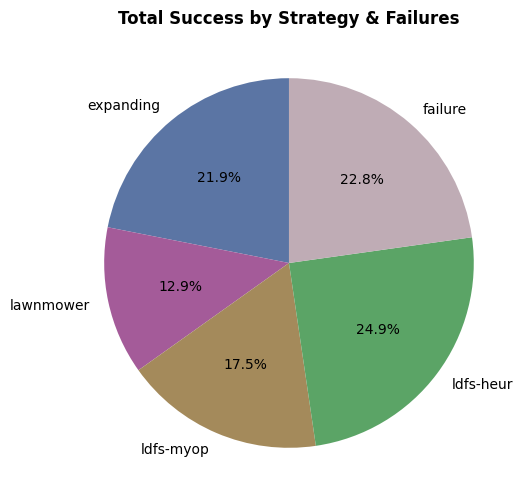

In [103]:
success_counts = combined_data_exp3_1[combined_data_exp3_1["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp3_1["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")


plt.savefig("graficas/exp-3-1-grande/pie-exito-total-3-1-grande.pdf")
plt.show()

# Caso de estudio 3 (Grande): Escenario 2 (`fixed`)
- indicios: 1, posición fija
- agentes: 1, posición fija
- escenario: grande

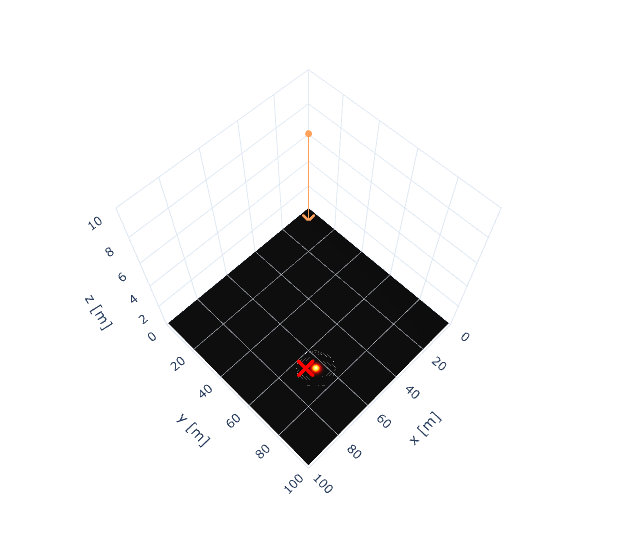

## Cargar los archivos

In [104]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "grande-indicios-1-agentes-1-fixed"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp3_2 = process_all(testing_path)

successful_df_exp3_2 = combined_data_exp3_2[combined_data_exp3_2["Found"]]

In [105]:
print(combined_data_exp3_2)

       Strategy  Number of Agents   Steps Steps finder   Distance  Found
0     expanding                 1   362.0        362.0   379.8112   True
1     expanding                 1   362.0        362.0   379.8112   True
2     expanding                 1   367.0        367.0   384.8112   True
3     expanding                 1   215.0        215.0   232.8112   True
4     expanding                 1   374.0        374.0   391.8112   True
...         ...               ...     ...          ...        ...    ...
3995  lawnmower                 1  1041.0       1041.0  1033.7279   True
3996  lawnmower                 1   899.0        899.0   892.7279   True
3997  lawnmower                 1   900.0        900.0   893.7279   True
3998  lawnmower                 1   905.0        905.0   898.7279   True
3999  lawnmower                 1  1038.0       1038.0  1030.7279   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [106]:
# Descripción general de los datos
combined_data_exp3_2.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,308.856,74.505304,212.0,215.0,364.0,368.0,375.0
lawnmower,1000.0,991.882,65.481860,899.0,905.0,1038.0,1041.0,1044.0
ldfs-heur,1000.0,73.757,20.240544,59.0,62.0,65.0,83.0,232.0
ldfs-myop,1000.0,1195.450,42.685379,533.0,1200.0,1200.0,1200.0,1200.0


In [107]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp3_2.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,368.0
lawnmower,1040.0
ldfs-heur,65.0
ldfs-myop,1200.0


In [108]:
combined_data_exp3_2.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000.0,17.0,385.8112,97.0
lawnmower,1000.0,18.0,1032.7279,83.0
ldfs-heur,1000.0,26.0,89.8528,133.0
ldfs-myop,1000,825,1289.119,5


#### Histogramas

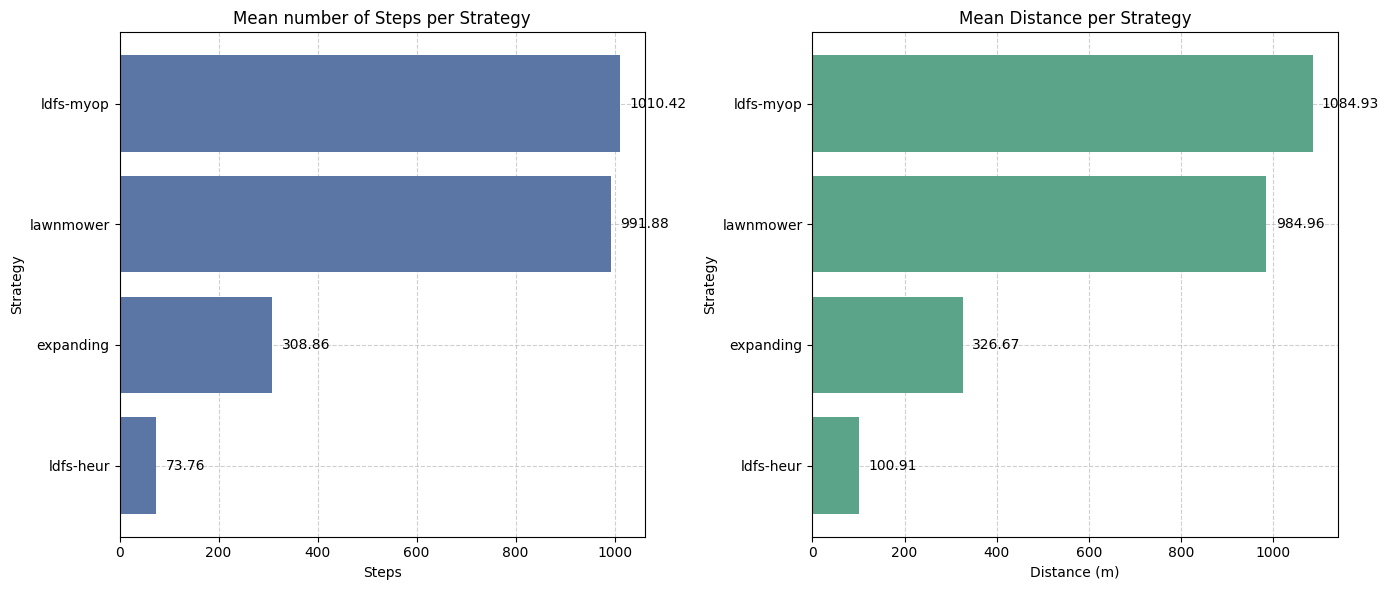

In [109]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp3_2.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp3_2.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-3-2-grande-fixed/histo-pasos-3-2-grande-fixed.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [110]:
execution_data = []

for strategy, group in combined_data_exp3_2.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [111]:
global_xmin = combined_data_exp3_2["Steps"].min()
global_xmax = combined_data_exp3_2["Steps"].max()
global_ymax = combined_data_exp3_2.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp3_2[combined_data_exp3_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas/exp-3-2-grande-fixed/histo-dist-3-2-grande-fixed.pdf")
fig_hist.show()

In [112]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp3_2[combined_data_exp3_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas/exp-3-2-grande-fixed/histo-dist-comb-3-2-grande-fixed.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [113]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp3_2[combined_data_exp3_2['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-3-2-grande-fixed/cdf-3-2-grande-fixed.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [114]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp3_2,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp3_2[combined_data_exp3_2['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-3-2-grande-fixed/boxplot-3-2-grande-fixed.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [115]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp3_2.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000       1000         100.0
lawnmower          1000       1000         100.0
ldfs-heur          1000       1000         100.0
ldfs-myop          1000         24           2.4


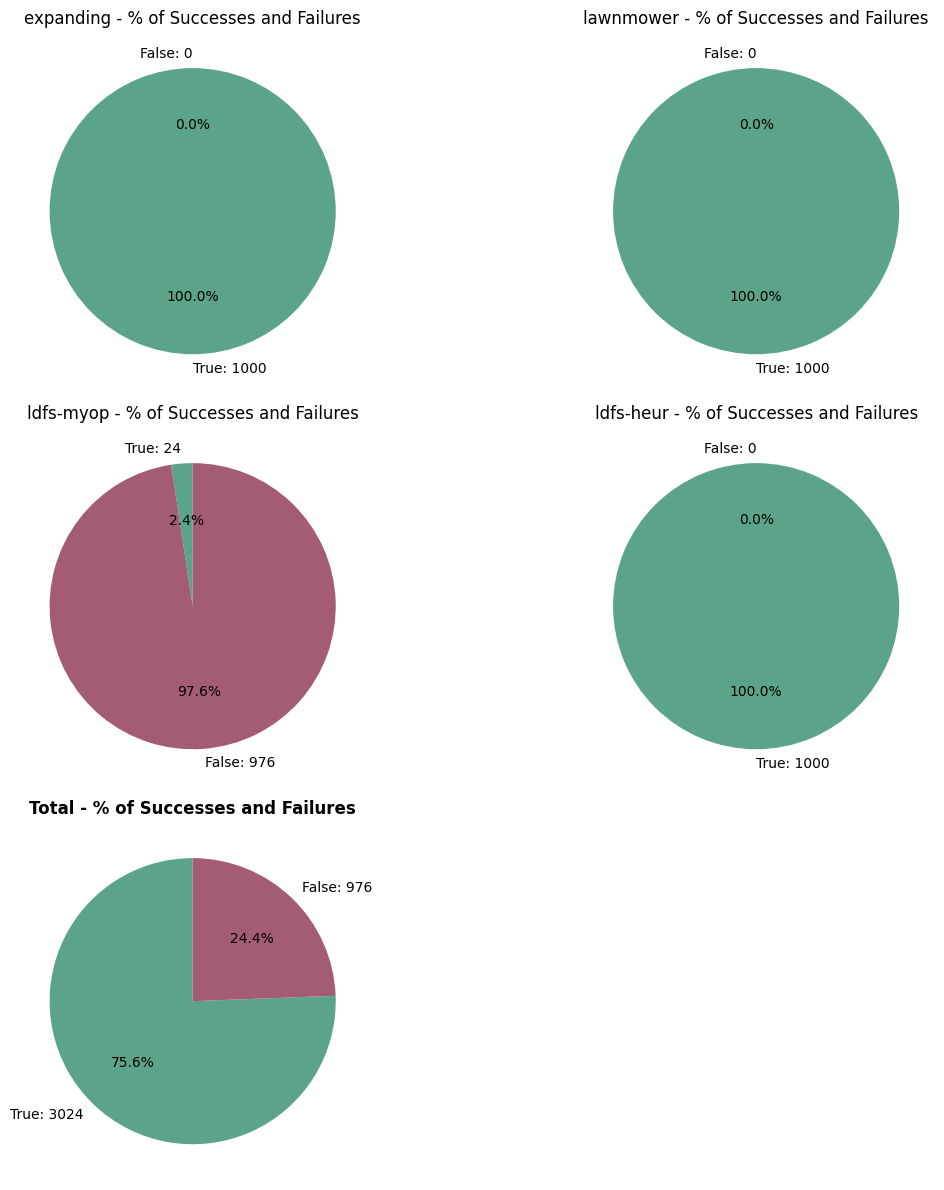

In [116]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp3_2[combined_data_exp3_2["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp3_2["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-3-2-grande-fixed/pie-exito-3-2-grande-fixed.pdf")
plt.show()

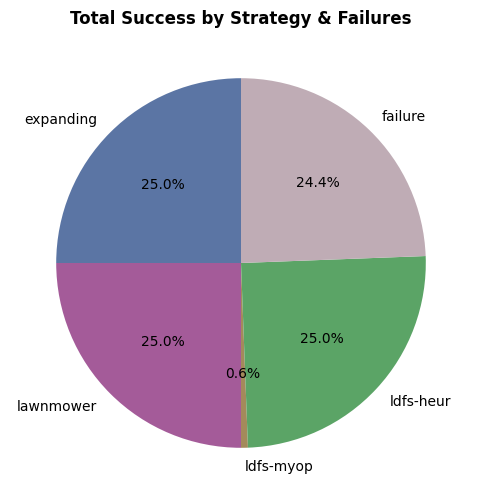

In [117]:
success_counts = combined_data_exp3_2[combined_data_exp3_2["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp3_2["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-3-2-grande-fixed/pie-exito-total-3-2-grande-fixed.pdf")
plt.show()

# Caso de estudio 3 (Grande): Escenario 3 (`random`)
- indicios: 1, posición aleatoria
- agentes: 1, posición fija
- escenario: grande

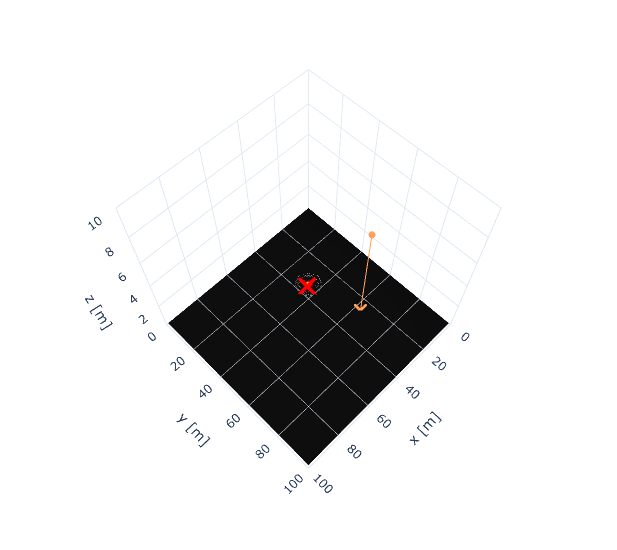

## Cargar los archivos

In [118]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "grande-indicios-1-agentes-1-random"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp3_3 = process_all(testing_path)

successful_df_exp3_3 = combined_data_exp3_3[combined_data_exp3_3["Found"]]

In [119]:
print(combined_data_exp3_3)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     expanding                 1   76.0         76.0   80.1421   True
1     expanding                 1  247.0        247.0  251.1421   True
2     expanding                 1  418.0        418.0  422.1421   True
3     expanding                 1  656.0        656.0  660.1421   True
4     expanding                 1  183.0        183.0  187.1421   True
...         ...               ...    ...          ...       ...    ...
3995  ldfs-heur                 1   17.0         17.0   20.7279   True
3996  ldfs-heur                 1   57.0         57.0   66.9411   True
3997  ldfs-heur                 1   54.0         54.0   72.2254   True
3998  ldfs-heur                 1   26.0         26.0   26.0711   True
3999  ldfs-heur                 1   47.0         47.0   54.8701   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [120]:
# Descripción general de los datos
combined_data_exp3_3.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,488.074,318.012135,1.0,225.75,458.5,738.00,1200.0
lawnmower,1000.0,691.741,377.706503,1.0,353.75,739.5,1029.25,1200.0
ldfs-heur,1000.0,32.717,15.907796,1.0,19.00,33.0,45.00,80.0
ldfs-myop,1000.0,754.957,526.822242,1.0,79.75,1200.0,1200.00,1200.0


In [121]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp3_3.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,1.0
lawnmower,1200.0
ldfs-heur,44.0
ldfs-myop,1200.0


In [122]:
combined_data_exp3_3.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000.0,620.0,1.0,11.0
lawnmower,1000,564,1194.0416,117
ldfs-heur,1000.0,711.0,18.3848,7.0
ldfs-myop,1000.0,875.0,9.8995,5.0


#### Histogramas

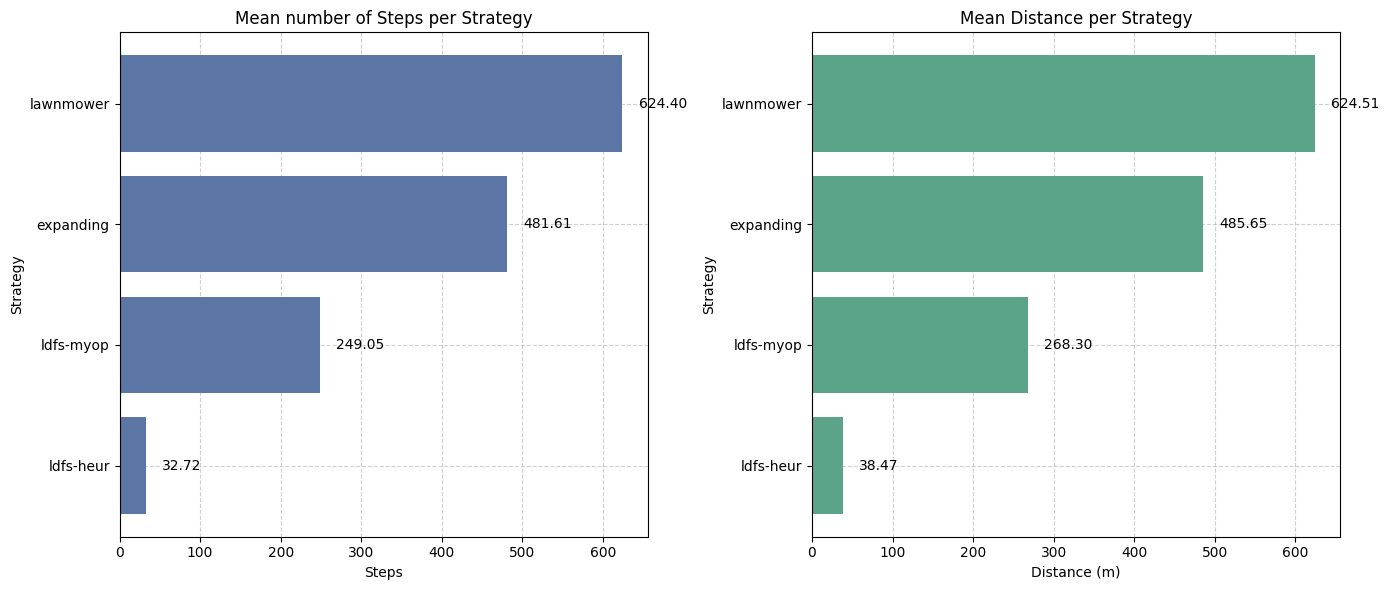

In [123]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp3_3.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp3_3.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas/exp-3-3-grande-random/histo-pasos-3-3-grande-random.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [124]:
execution_data = []

for strategy, group in combined_data_exp3_3.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [125]:
global_xmin = combined_data_exp3_3["Steps"].min()
global_xmax = combined_data_exp3_3["Steps"].max()
global_ymax = combined_data_exp3_3.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp3_3[combined_data_exp3_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas/exp-3-3-grande-random/histo-dist-3-3-grande-random.pdf")
fig_hist.show()

In [126]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp3_3[combined_data_exp3_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas/exp-3-3-grande-random/histo-dist-comb-3-3-grande-random.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [127]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp3_3[combined_data_exp3_3['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas/exp-3-3-grande-random/cdf-3-3-grande-random.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [128]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp3_3,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp3_3[combined_data_exp3_3['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas/exp-3-3-grande-random/boxplot-3-3-grande-random.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [129]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp3_3.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000        991          99.1
lawnmower          1000        883          88.3
ldfs-heur          1000       1000         100.0
ldfs-myop          1000        468          46.8


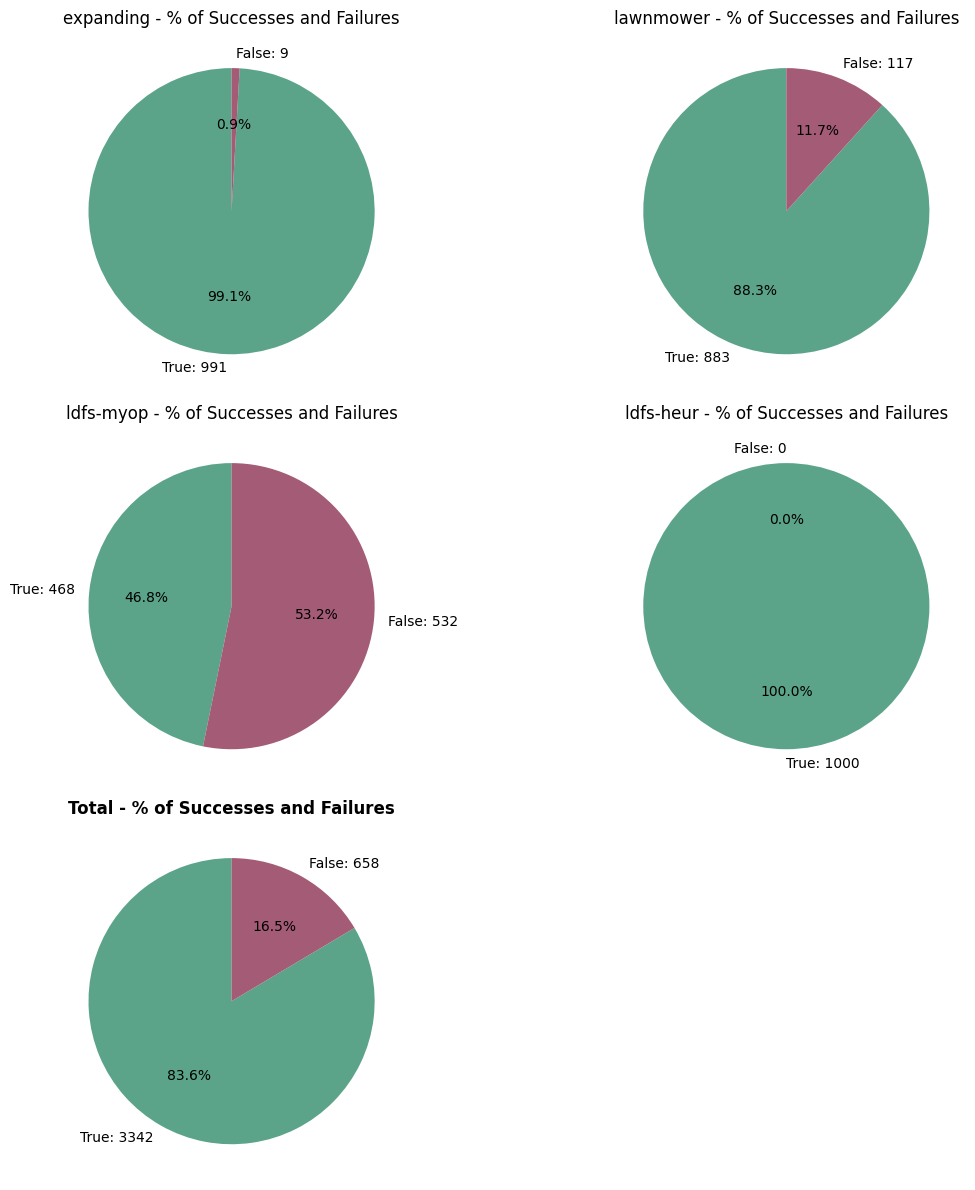

In [130]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp3_3[combined_data_exp3_3["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp3_3["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas/exp-3-3-grande-random/pie-exito-3-3-grande-random.pdf")
plt.show()

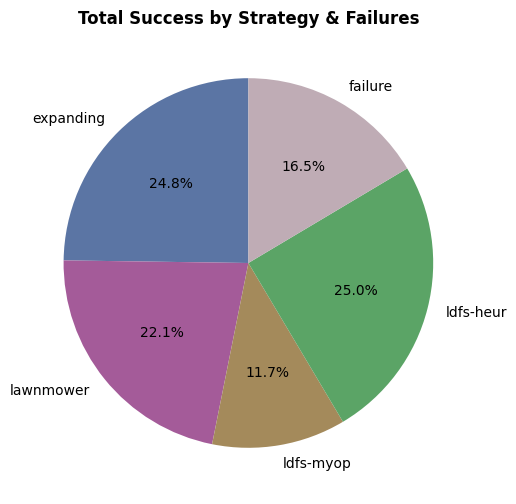

In [131]:
success_counts = combined_data_exp3_3[combined_data_exp3_3["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp3_3["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas/exp-3-3-grande-random/pie-exito-total-3-3-grande-random.pdf")
plt.show()

# Limpiar entorno

In [132]:
drive.flush_and_unmount()